### Survival Analysis and Censored Data

In this chapter, we will consider the topics of survival analysis and censored
data. These arise in the analysis of a unique kind of outcome variable: the
time until an event occurs.

For example, suppose that we have conducted a five-year medical study,
in which patients have been treated for cancer. We would like to fit a model
to predict patient survival time, using features such as baseline health measurements or type of treatment. At first pass, this may sound like a regres
sion problem of the kind discussed in Chapter 3. But there is an important
complication: hopefully some or many of the patients have survived until
the end of the study. Such a patient’s survival time is said to be censored: we
know that it is at least five years, but we do not know its true value. We do
not want to discard this subset of surviving patients, as the fact that they
survived at least five years amounts to valuable information. However, it is
not clear how to make use of this information using the techniques covered
thus far in this textbook.

Though the phrase “survival analysis” evokes a medical study, the applications of survival analysis extend far beyond medicine. For example,
consider a company that wishes to model churn, the process by which cus
tomers cancel subscription to a service. The company might collect data on
customers over some time period, in order to model each customer’s time
to cancellation as a function of demographics or other predictors. However,
presumably not all customers will have canceled their subscription by the
end of this time period; for such customers, the time to cancellation is
censored.

In fact, survival analysis is relevant even in application areas that are
unrelated to time. For instance, suppose we wish to model a person’s weight
as a function of some covariates, using a dataset with measurements for a
large number of people. Unfortunately, the scale used to weigh those people
is unable to report weights above a certain number. Then, any weights that
exceed that number are censored. The survival analysis methods presented
in this chapter could be used to analyze this dataset.

Survival analysis is a very well-studied topic within statistics, due to its
critical importance in a variety of applications, both in and out of medicine.
However, it has received relatively little attention in the machine learning
community.

####  Survival and Censoring Times

For each individual, we suppose that there is a true survival time, $ T $, as well as a true censoring time, $ C $. (The survival time is also known as the failure time or the event time.) The survival time represents the time at which the event of interest occurs: for instance, the time at which the patient dies, or the customer cancels his or her subscription. By contrast, the censoring time is the time at which censoring occurs: for example, the time at which the patient drops out of the study or the study ends.

We observe either the survival time $ T $ or else the censoring time $ C $. Specifically, we observe the random variable

$$
Y = \min(T, C). \tag{11.1}
$$ 

In other words, if the event occurs before censoring (i.e. $ T < C $), then we observe the true survival time $ T $; however, if censoring occurs before the event ($ T > C $), then we observe the censoring time. We also observe a status indicator,

$$
\delta =
\begin{cases} 
1 & \text{if } T \leq C \\ 
0 & \text{if } T > C 
\end{cases}
$$

Thus, $ \delta = 1 $ if we observe the true survival time, and $ \delta = 0 $ if we instead observe the censoring time.

Now, suppose we observe $ n $ $ (Y, \delta) $ pairs, which we denote as $ (y_1, \delta_1), \ldots, (y_n, \delta_n) $. Figure 11.1 displays an example from a (fictitious) medical study in which we observe $ n = 4 $ patients for a 365-day follow-up period. For patients 1 and 3, we observe the time to event (such as death or disease relapse) $ T = t_i $. Patient 2 was alive when the study ended, and patient 4 dropped out of the study, or was “lost to follow-up”; for these patients we observe $ C = c_i $. Therefore, $ y_1 = t_1, y_3 = t_3, y_2 = c_2, y_4 = c_4, \delta_1 = \delta_3 = 1, $ and $ \delta_2 = \delta_4 = 0 $.



#### A Closer Look at Censoring

In order to analyze survival data, we need to make some assumptions about why censoring has occurred. For instance, suppose that a number of patients drop out of a cancer study early because they are very sick. An analysis that does not take into consideration the reason why the patients dropped out will likely overestimate the true average survival time. Similarly, suppose that males who are very sick are more likely to drop out of the study than females who are very sick. Then a comparison of male and female survival times may wrongly suggest that males survive longer than females.

In general, we need to assume that the censoring mechanism is independent: conditional on the features, the event time $ T $ is independent of the censoring time $ C $. The two examples above violate the assumption of independent censoring. Typically, it is not possible to determine from the data itself whether the censoring mechanism is independent. Instead, one has to carefully consider the data collection process in order to determine whether independent censoring is a reasonable assumption. In the remainder of this chapter, we will assume that the censoring mechanism is independent.¹

In this chapter, we focus on right censoring, which occurs when $ T \geq Y $, i.e., the true event time $ T $ is at least as large as the observed time $ Y $. (Notice that $ T \geq Y $ is a consequence of (11.1). Right censoring derives its name from the fact that time is typically displayed from left to right, as in Figure 11.1.) However, other types of censoring are possible. For instance, in left censoring, the true event time $ T $ is less than or equal to the observed time $ Y $. For example, in a study of pregnancy duration, suppose that we survey patients 250 days after conception, when some have already had their babies. Then we know that for those patients, pregnancy duration is less than 250 days. More generally, interval censoring refers to the setting in which we do not know the exact event time, but we know that it falls in some interval. For instance, this setting arises if we survey patients once per week in order to determine whether the event has occurred. While left censoring and interval censoring can be accommodated using variants of the ideas presented in this chapter, in what follows we focus specifically on right censoring.

#### The Kaplan–Meier Survival Curve

The survival curve, or survival function, is defined as

$$
S(t) = \Pr(T > t). \tag{11.2}
$$ 
This decreasing function quantifies the probability of surviving past time $ t $. For example, suppose that a company is interested in modeling customer churn. Let $ T $ represent the time that a customer cancels a subscription to the company’s service. Then $ S(t) $ represents the probability that a customer cancels later than time $ t $. The larger the value of $ S(t) $, the less likely that the customer will cancel before time $ t $.

In this section, we will consider the task of estimating the survival curve. Our investigation is motivated by the BrainCancer dataset, which contains the survival times for patients with primary brain tumors undergoing treatment with stereotactic radiation methods.² The predictors are gtv (gross tumor volume, in cubic centimeters); sex (male or female); diagnosis (meningioma, LG glioma, HG glioma, or other); loc (the tumor location: either infratentorial or supratentorial); ki (Karnofsky index); and stereo (stereotactic method: either stereotactic radiosurgery or fractionated stereotactic radiotherapy, abbreviated as SRS and SRT, respectively). Only 53 of the 88 patients were still alive at the end of the study.

Now, we consider the task of estimating the survival curve (11.2) for these data. To estimate $ S(20) = \Pr(T > 20) $, the probability that a patient survives for at least $ t = 20 $ months, it is tempting to simply compute the proportion of patients who are known to have survived past 20 months, i.e., the proportion of patients for whom $ Y > 20 $. This turns out to be $ 48/88 $, or approximately 55%. However, this does not seem quite right, since $ Y $ and $ T $ represent different quantities. In particular, 17 of the 40 patients who did not survive to 20 months were actually censored, and this analysis implicitly assumes that $ T < 20 $ for all of those censored patients; of course, we do not know whether that is true.

Alternatively, to estimate $ S(20) $, we could consider computing the proportion of patients for whom $ Y > 20 $, out of the 71 patients who were not censored by time $ t = 20 $; this comes out to $ 48/71 $, or approximately 68%. However, this is not quite right either, since it amounts to completely ignoring the patients who were censored before time $ t = 20 $, even though the time at which they are censored is potentially informative. For instance, a patient who was censored at time $ t = 19.9 $ likely would have survived past $ t = 20 $ had he or she not been censored.

We have seen that estimating $ S(t) $ is complicated by the presence of censoring. We now present an approach to overcome these challenges. We let $ d_1 < d_2 < \cdots < d_K $ denote the $ K $ unique death times among the non-censored patients, and we let $ q_k $ denote the number of patients who died at time $ d_k $. For $ k = 1, \ldots, K $, we let $ r_k $ denote the number of patients alive and in the study just before $ d_k $; these are the at risk patients. The set of patients that are at risk at a given time are referred to as the risk set.

By the law of total probability,³

$$
\Pr(T > d_k) = \Pr(T > d_k | T > d_{k-1}) \Pr(T > d_{k-1}) + \Pr(T > d_k | T \leq d_{k-1}) \Pr(T \leq d_{k-1}).
$$

The fact that $ d_{k-1} < d_k $ implies that $ \Pr(T > d_k | T \leq d_{k-1}) = 0 $ (it is impossible for a patient to survive past time $ d_k $ if he or she did not survive until an earlier time $ d_{k-1} $). Therefore,

$$
S(d_k) = \Pr(T > d_k) = \Pr(T > d_k | T > d_{k-1}) \Pr(T > d_{k-1}).
$$

Plugging in (11.2) again, we see that

$$
S(d_k) = \Pr(T > d_k | T > d_{k-1}) S(d_{k-1}).
$$

This implies that

$$
S(d_k) = \Pr(T > d_k | T > d_{k-1}) \cdots \Pr(T > d_2 | T > d_1) \Pr(T > d_1).
$$

We now must simply plug in estimates of each of the terms on the right-hand side of the previous equation. It is natural to use the estimator

$$
\Pr(T > d_j | T > d_{j-1}) = \frac{r_j - q_j}{r_j},
$$

which is the fraction of the risk set at time $ d_j $ who survived past time $ d_j $. This leads to the Kaplan–Meier estimator of the survival curve:

$$
\hat{S}(d_k) = \prod_{j=1}^{k} \frac{r_j - q_j}{r_j} \tag{11.3}
$$ 

For times $ t $ between $ d_k $ and $ d_{k+1} $, we set $ S(t) = S(d_k) $. Consequently, the Kaplan–Meier survival curve has a step-like shape.

The Kaplan–Meier survival curve for the BrainCancer data is displayed in Figure 11.2. Each point in the solid step-like curve shows the estimated probability of surviving past the time indicated on the horizontal axis. The estimated probability of survival past 20 months is 71%, which is quite a bit higher than the naive estimates of 55% and 68% presented earlier.

The sequential construction of the Kaplan–Meier estimator — starting at time zero and mapping out the observed events as they unfold in time — is fundamental to many of the key techniques in survival analysis. These include the log-rank test of Section 11.4, and Cox’s proportional hazard
model of Section 11.5.2.

#### The Log-Rank Test

We now continue our analysis of the `BrainCancer` data introduced in Sec
tion 11.3. We wish to compare the survival of males to that of females.
Figure 11.3 shows the Kaplan–Meier survival curves for the two groups.
Females seem to fare a little better up to about 50 months, but then the
two curves both level off to about 50%. How can we carry out a formal test
of equality of the two survival curves?

At first glance, a two-sample t-test seems like an obvious choice: we could
test whether the mean survival time among the females equals the mean
survival time among the males. But the presence of censoring again creates
a complication. To overcome this challenge, we will conduct a log-rank test, which examines how the events in each group unfold sequentially in time. Recall from Section 11.3 that $ d_1 < d_2 < \cdots < d_K $ are the unique death times among the non-censored patients, $ r_k $ is the number of patients at risk at time $ d_k $, and $ q_k $ is the number of patients who died at time $ d_k $. We further define $ r_{1k} $ and $ r_{2k} $ to be the number of patients in groups 1 and 2, respectively, who are at risk at time $ d_k $. Similarly, we define $ q_{1k} $ and $ q_{2k} $ to be the number of patients in groups 1 and 2, respectively, who died at time $ d_k $. Note that $ r_{1k} + r_{2k} = r_k $ and $ q_{1k} + q_{2k} = q_k $.

|                | Group 1 | Group 2 | Total  |
|----------------|---------|---------|--------|
| Died           | $ q_{1k} $ | $ q_{2k} $ | $ q_k $ |
| Survived       | $ r_{1k} $ | $ q_{1k} $ | $ r_{2k} $ | $ q_{2k} $ | $ r_k $ | $ q_k $ |
| Total          | $ r_{1k} $ | $ r_{2k} $ | $ r_k $ |

**TABLE 11.1.** Among the set of patients at risk at time $ d_k $, the number of patients who died and survived in each of two groups is reported.



At each death time $ d_k $, we construct a $ 2 \times 2 $ table of counts of the form shown in Table 11.1. Note that if the death times are unique (i.e. no two individuals die at the same time), then one of $ q_{1k} $ and $ q_{2k} $ equals one, and the other equals zero.

The main idea behind the log-rank test statistic is as follows. In order to test $ H_0 : E(X) = \mu $ for some random variable $ X $, one approach is to construct a test statistic of the form

$$
W = \frac{X - \mu}{\text{Var}(X)}. \tag{11.4}
$$ 


To construct the log-rank test statistic, we compute a quantity that takes exactly the form (11.4), with $ X = \sum_{k=1}^{K} q_{1k} $, where $ q_{1k} $ is given in the top left of Table 11.1.

In greater detail, if there is no difference in survival between the two groups, and conditioning on the row and column totals in Table 11.1, the expected value of $ q_{1k} $ is 

$$
\mu_k = \frac{r_{1k}}{r_k} q_k. \tag{11.5}
$$

So the expected value of $ X = \sum_{k=1}^{K} q_{1k} $ is $ \mu = \sum_{k=1}^{K} \frac{r_{1k}}{r_k} q_k$. Furthermore, it can be shown that the variance of $ q_{1k} $ is 

$$
\text{Var}(q_{1k}) = \frac{q_k (r_{1k}/r_k)(1 - r_{1k}/r_k)(r_k - q_k)}{r_k - 1}. \tag{11.6}
$$

Though $ q_{11},\ldots,q_{1K} $ may be correlated, we nonetheless estimate 

$$
\text{Var}\left(\sum_{k=1}^{K}q_{1k}\right) \approx \sum_{k=1}^{K} \text{Var}(q_{1k}) = \sum_{k=1}^{K}\frac{q_k(r_{1k}/r_k)(1 - r_{1k}/r_k)(r_k - q_k)}{r_k - 1}. \tag{11.7}
$$

in (11.4), with $ X = \sum_{k=1}^{K} q_{1k} $, making use of (11.5) and (11.7). That is, we calculate

$$
W = \frac{\sum_{k=1}^{K} (q_{1k} - \mu_k)}{\sqrt{\sum_{k=1}^{K} \text{Var}(q_{1k})}} = \frac{\sum_{k=1}^{K} (q_{1k} -\frac{q_k}{r_k}r_{1k})}{\sqrt{\sum_{k=1}^{K} \frac{ q_k (r_{1k}/r_k)(1 - r_{1k}/r_k)(r_k - q_k)}{r_k - 1}}}. \tag{11.8}
$$


When the sample size is large, the log-rank test statistic $ W $ has approximately a standard normal distribution; this can be used to compute a p-value for the null hypothesis that there is no difference between the survival curves in the two groups.⁶ Comparing the survival times of females and males on the BrainCancer data gives a log-rank test statistic of $ W = 1.2 $, which corresponds to a two-sided p-value of 0.2 using the theoretical null distribution, and a p-value of 0.25 using the permutation null distribution with 1,000 permutations. Thus, we cannot reject the null hypothesis of no difference in survival curves between females and males.

The log-rank test is closely related to Cox’s proportional hazards model, which we discuss in Section 11.5.2.



#### Regression Models With a Survival Response



We now consider the task of fitting a regression model to survival data. As in Section 11.1, the observations are of the form $ (Y, \delta) $, where $ Y = \min(T, C) $ is the (possibly censored) survival time, and $ \delta $ is an indicator variable that equals 1 if $ T \leq C $. Furthermore, $ X \in \mathbb{R}^p $ is a vector of $ p $ features. We wish to predict the true survival time $ T $.

Since the observed quantity $ Y $ is positive and may have a long right tail, we might be tempted to fit a linear regression of $ \log(Y) $ on $ X $. But as the reader will surely guess, censoring again creates a problem since we are actually interested in predicting $ T $ and not $ Y $. To overcome this difficulty, we instead make use of a sequential construction, similar to the constructions of the Kaplan–Meier survival curve in Section 11.3 and the log-rank test in Section 11.4.


#####  The Hazard Function


The hazard function or hazard rate — also known as the force of mortality hazard — is formally defined as

$$
h(t) = \lim_{\Delta t \to 0} \frac{\Pr(t < T \leq t + \Delta t | T > t)}{\Delta t}. \tag{11.9}
$$

where $ T $ is the (unobserved) survival time. It is the death rate in the instant after time $ t $, given survival past that time.⁷ In (11.9), we take the limit as $ t $ approaches zero, so we can think of $ t $ as being an extremely tiny number. Thus, more informally, (11.9) implies that 

$$
h(t) \approx \frac{\Pr(t < T \leq t + t | T > t)}{t}
$$

for some arbitrarily small $ t $.

Why should we care about the hazard function? First of all, it is closely related to the survival curve (11.2), as we will see next. Second, it turns out that a key approach for modeling survival data as a function of covariates relies heavily on the hazard function; we will introduce this approach — Cox’s proportional hazards model — in Section 11.5.2.

We now consider the hazard function $ h(t) $ in a bit more detail. Recall that for two events $ A $ and $ B $, the probability of $ A $ given $ B $ can be expressed as 

$$
\Pr(A | B) = \frac{\Pr(A \cap B)}{\Pr(B)},
$$

i.e., the probability that $ A $ and $ B $ both occur divided by the probability that $ B $ occurs. Furthermore, recall from (11.2) that $ S(t) = \Pr(T > t) $. Thus,

$$
h(t) = \lim_{\Delta t \to 0} \frac{\Pr((t < T \leq t + t) \cap (T > t))}{t} = \frac{\Pr(T > t)}{\lim_{\Delta t \to 0} t}
= \lim_{\Delta t \to 0} \frac{\Pr(t < T \leq t + t)}{t} \cdot \frac{1}{\Pr(T > t)} = \frac{f(t)}{S(t)}, \tag{11.10}
$$

where 

$$
f(t) = \lim_{\Delta t \to 0} \frac{\Pr(t < T \leq t + t)}{t} \tag{11.11}
$$



is the probability density function associated with $ T $, i.e., it is the instantaneous rate of death at time $ t $. The second equality in (11.10) made use of the fact that if $ t < T \leq t + t $, then it must be the case that $ T > t $.

Equation (11.10) implies a relationship between the hazard function $ h(t) $, the survival function $ S(t) $, and the probability density function $ f(t) $. In fact, these are three equivalent ways⁸ of describing the distribution of $ T $.

The likelihood associated with the $ i $-th observation is 

$$
L_i = 
\begin{cases} 
f(y_i) & \text{if the } i\text{-th observation is not censored} \\
S(y_i) & \text{if the } i\text{-th observation is censored} 
\end{cases}
= f(y_i) \cdot I_{\{S(y_i) = 1\}}. \tag{11.12}
$$


The intuition behind (11.12) is as follows: if $ Y = y_i $ and the $ i $-th observation is not censored, then the likelihood is the probability of dying in a tiny interval around time $ y_i $. If the $ i $-th observation is censored, then the likelihood is the probability of surviving at least until time $y_i$. Assuming that the $n$ observations are independent, the likelihood for the data takes the form 

$$
L = \prod_{i=1}^{n} \left( f(y_i) I_{\{S(y_i) = 1\}} \right) = \prod_{i=1}^{n} \left( h(y_i) I_{\{S(y_i)\}} \right), \tag{11.13}
$$

(11.13) where the second equality follows from (11.10).

We now consider the task of modeling the survival times. If we assume exponential survival, i.e. that the probability density function of the survival time $ T $ takes the form $ f(t) = \exp(-\lambda t) $, then estimating the parameter $ \lambda $ by maximizing the likelihood in (11.13) is straightforward.⁹ Alternatively, we could assume that the survival times are drawn from a more flexible family of distributions, such as the Gamma or Weibull family. Another possibility is to model the survival times non-parametrically, as was done in Section 11.3 using the Kaplan–Meier estimator.

However, what we would really like to do is model the survival time as a function of the covariates. To do this, it is convenient to work directly with the hazard function, instead of the probability density function.¹⁰ One possible approach is to assume a functional form for the hazard function $ h(t | x_i) $, such as $h(t | x_i) = \exp\left(\beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}\right), $

where the exponent function guarantees that the hazard function is non-negative. Note that the exponential hazard function is special, in that it does not vary with time.¹¹ Given $ h(t | x_i) $, we could calculate $ S(t | x_i) $. Plugging these equations into (11.13), we could then maximize the likelihood in order to estimate the parameter $ \beta = (\beta_0, \beta_1, \ldots, \beta_p)^T $. However, this approach is quite restrictive, in the sense that it requires us to make a very stringent assumption on the form of the hazard function $ h(t | x_i) $. In the next section, we will consider a much more flexible approach.


##### Proportional Hazards


The Proportional Hazards Assumption


The proportional hazards assumption states that 

$$
h(t | x_i) = h_0(t) \exp\left(\sum_{j=1}^{p} x_{ij} \beta_j\right), \tag{11.14}
$$

(11.14) where $ h_0(t) $ is an unspecified function, known as the baseline hazard. It is the hazard function for an individual with features $ x_{i1} = \cdots = x_{ip} = 0 $. The name “proportional hazards” arises from the fact that the hazard function for an individual with feature vector $ x_i $ is some unknown function $ h_0(t) $ times the factor 

$$
\exp\left(\sum_{j=1}^{p} x_{ij} \beta_j\right).
$$

The quantity 

$$
\exp\left(\sum_{j=1}^{p} x_{ij} \beta_j\right)
$$

is called the relative risk for the feature vector $ \mathbf{x}_i = (x_{i1}, \ldots, x_{ip})^T $, relative to that for the feature vector $ \mathbf{x}_i = (0, \ldots, 0)^T $.

What does it mean that the baseline hazard function $ h_0(t) $ in (11.14) is unspecified? Basically, we make no assumptions about its functional form. We allow the instantaneous probability of death at time $ t $, given that one has survived at least until time $ t $, to take any form. This means that the hazard function is very flexible and can model a wide range of relationships between the covariates and survival time. Our only assumption is that a one-unit increase in $ x_{ij} $ corresponds to an increase in $ h(t|x_i) $ by a factor of $ \exp(\beta_j) $.

An illustration of the proportional hazards assumption (11.14) is given in Figure 11.4, in a simple setting with a single binary covariate $ x_i \in \{0,1\} $ (so that $ p = 1 $). In the top row, the proportional hazards assumption (11.14) holds. Thus, the hazard functions of the two groups are a constant multiple of each other, so that on the log scale, the gap between them is constant. Furthermore, the survival curves never cross, and in fact the gap between the survival curves tends to (initially) increase over time. By contrast, in the bottom row, (11.14) does not hold. We see that the log hazard functions for the two groups cross, as do the survival curves.

Cox’s Proportional Hazards Model

Because the form of $ h_0(t) $ in the proportional hazards assumption (11.14) is unknown, we cannot simply plug $ h(t|x_i) $ into the likelihood (11.13) and then estimate $ \beta = (\beta_1, \ldots, \beta_p)^T $ by maximum likelihood. The magic of Cox’s proportional hazards model lies in the fact that it is in fact possible to estimate $ \beta $ without having to specify the form of $ h_0(t) $.

To accomplish this, we make use of the same “sequential in time” logic that we used to derive the Kaplan–Meier survival curve and the log-rank test. For simplicity, assume that there are no ties among the failure, or death, times: i.e., each failure occurs at a distinct time. Assume that $ \delta_i = 1 $, i.e., the $ i $th observation is uncensored, and thus $ y_i $ is its failure time. Then the hazard function for the $ i $th observation at time $ y_i $ is 

$$
h(y_i | x_i) = h_0(y_i) \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right),
$$ 

and the total hazard at time $ y_i $ for the at-risk observations is 

$$
\sum_{i: y_i \geq y_i} h_0(y_i) \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right).
$$

Therefore, the probability that the $ i $th observation is the one to fail at time $ y_i $ (as opposed to one of the other observations in the risk set) is 

$$
\frac{h_0(y_i) \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}{\sum_{i: y_i \geq y_i} h_0(y_i) \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)} = \frac{\exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}{\sum_{i: y_i \geq y_i} \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}. \tag{11.15}
$$ 


Notice that the unspecified baseline hazard function $ h_0(y_i) $ cancels out of the numerator and denominator!

The partial likelihood is simply the product of these probabilities over all uncensored observations: 

$$
PL(\beta) = \prod_{i: \delta_i=1} \frac{\exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}{\sum_{i: y_i \geq y_i} \exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}. \tag{11.16}
$$ 

Critically, the partial likelihood is valid regardless of the true value of $ h_0(t) $, making the model very flexible and robust.¹³

To estimate $ \beta $, we simply maximize the partial likelihood (11.16) with respect to $ \beta $. As was the case for logistic regression in Chapter 4, no closed form solution is available, and so iterative algorithms are required.

In addition to estimating $ \beta $, we can also obtain other model outputs that we saw in the context of least squares regression in Chapter 3 and logistic regression in Chapter 4. For example, we can obtain p-values corresponding to particular null hypotheses (e.g. $ H_0 : \beta_j = 0 $), as well as confidence intervals associated with the coefficients.


Connection With The Log-Rank Test



Suppose we have just a single predictor ($ p = 1 $), which we assume to be binary, i.e. $ x_i \in \{0, 1\} $. In order to determine whether there is a difference between the survival times of the observations in the group $ \{i : x_i = 0\} $ and those in the group $ \{i : x_i = 1\} $, we can consider taking two possible approaches:

> $Approach$ #1: Fit a Cox proportional hazards model, and test the null hypothesis $ H_0 : \beta = 0 $. (Since $ p = 1 $, $ \beta $ is a scalar.)
>
> $Approach$ #2: Perform a log-rank test to compare the two groups, as in Section 11.4.

Which one should we prefer? 

In fact, there is a close relationship between these two approaches. In particular, when taking Approach #1, there are a number of possible ways to test $ H_0 $. One way is known as a score test. It turns out that in the case of a single binary covariate, the score test for $ H_0 : \beta = 0 $ in Cox’s proportional hazards model is exactly equal to the log-rank test. In other words, it does not matter whether we take Approach #1 or Approach #2!


Additional Details

The discussion of Cox’s proportional hazards model glossed over a few subtleties:

- There is no intercept in (11.14) nor in the equations that follow, because an intercept can be absorbed into the baseline hazard $ h_0(t) $.

- We have assumed that there are no tied failure times. In the case of ties, the exact form of the partial likelihood (11.16) is a bit more complicated, and a number of computational approximations must be used.

- (11.16) is known as the partial likelihood because it is not exactly a likelihood. That is, it does not correspond exactly to the probability of the data under the assumption (11.14). However, it is a very good approximation.

- We have focused only on estimation of the coefficients $ \beta = (\beta_1, \ldots, \beta_p)^T $. However, at times we may also wish to estimate the baseline hazard $ h_0(t) $, for instance so that we can estimate the survival curve $ S(t|x) $ for an individual with feature vector $ x $. The details are beyond the scope of this book. Estimation of $ h_0(t) $ is implemented in the lifelines package in Python, which we will see in Section 11.8.

##### Example: Brain Cancer Data

Table 11.2 shows the result of fitting the proportional hazards model to the `BrainCancer` data, which was originally described in Section 11.3. The coefficient column displays $ \hat{\beta}_j $. The results indicate, for instance, that the estimated hazard for a male patient is $ e^{0.18} = 1.2 $ times greater than for a female patient: in other words, with all other features held fixed, males have a 1.2 times greater chance of dying than females, at any point in time. However, the p-value is 0.61, which indicates that this difference between males and females is not significant.

As another example, we also see that each one-unit increase in the Karnofsky index corresponds to a multiplier of $ \exp(0.05) = 0.95 $ in the instantaneous chance of dying. In other words, the higher the Karnofsky index, the lower the chance of dying at any given point in time. This effect is highly significant, with a p-value of 0.0027.

| |$Coefficient $                      | $Std.$ $error$ | $z-statistic$ | $p-value$ |
|--|---------------------------------|------------|-------------|---------|
| `sex[Male]`                         | 0.18      | 0.36       | 0.51    | 0.61 |
| `diagnosis[LG Glioma]`             | 0.92   | 0.64   | 1.43       | 0.15    |
| `diagnosis[HG Glioma]`            | 2.15     | 0.45 | 4.78       | 0.00   |
| `diagnosis[Other]`                 | 0.89  | 0.66    | 1.35       | 0.18    |
| `loc[Supratentorial]`              | 0.44  | 0.70    | 0.63       | 0.53    |
| `ki`                                | -0.05 | 0.02    | -3.00      | <0.01   |
| `gtv`                               | 0.03      | 0.02       | 1.54    | 0.12 |
| `stereo[SRT]`                      | 0.18      | 0.60       | 0.30    | 0.77

**TABLE 11.2.** Results for Cox’s proportional hazards model fit to the `BrainCancer` data, which was first described in Section 11.3. The variable `diagnosis` is qualitative with four levels: meningioma, LG glioma, HG glioma, or other. The variables `sex`, `loc`, and `stereo` are binary.



##### Example: Publication Data

Next, we consider the dataset `Publication` involving the time to publication of journal papers reporting the results of clinical trials funded by the National Heart, Lung, and Blood Institute. For 244 trials, the time in months until publication is recorded. Of the 244 trials, only 156 were published during the study period; the remaining studies were censored. The covariates include whether the trial focused on a clinical endpoint (`clinend`), whether the trial involved multiple centers (`multi`), the funding mechanism within the National Institutes of Health (`mech`), trial sample size (`sampsize`), budget (`budget`), impact (`impact`, related to the number of citations), and whether the trial produced a positive (significant) result (`posres`). The last covariate is particularly interesting, as a number of studies have suggested that positive trials have a higher publication rate.

Figure 11.5 shows the Kaplan–Meier curves for the time until publication, stratified by whether or not the study produced a positive result. We see slight evidence that time until publication is lower for studies with a positive result. However, the log-rank test yields a very unimpressive p-value of 0.36.

We now consider a more careful analysis that makes use of all of the available predictors. The results of fitting Cox’s proportional hazards model using all of the available features are shown in Table 11.3. We find that the chance of publication of a study with a positive result is $ e^{0.55} = 1.74 $ times higher than the chance of publication of a study with a negative result at any point in time, holding all other covariates fixed. The very small p-value associated with posres in Table 11.3 indicates that this result is highly significant. This is striking, especially in light of our earlier finding that a log-rank test comparing time to publication for studies with positive versus negative results yielded a p-value of 0.36. How can we explain this discrepancy? The answer stems from the fact that the log-rank test did not consider any other covariates, whereas the results in Table 11.3 are based on a Cox model using all of the available covariates. In other words, after we adjust for all of the other covariates, then whether or not the study yielded a positive result is highly predictive of the time to publication.

In order to gain more insight into this result, in Figure 11.6 we display estimates of the survival curves associated with positive and negative results, adjusting for the other predictors. To produce these survival curves, we estimated the underlying baseline hazard $ h_0(t) $. We also needed to select representative values for the other predictors; we used the mean value for each predictor, except for the categorical predictor mech, for which we used the most prevalent category (R01). Adjusting for the other predictors, we now see a clear difference in the survival curves between studies with positive versus negative results.

Other interesting insights can be gleaned from Table 11.3. For example, studies with a clinical endpoint are more likely to be published at any given point in time than those with a non-clinical endpoint. The funding mechanism did not appear to be significantly associated with time until publication.



|                     | $Coefficient$ | $Std.$ $error$ | $z-statistic$ | $p-value$ |
|----------------------|-------------|------------|-------------|---------|
| `posres[Yes]`         | 0.55        | 0.18       | 3.02        | 0.00    |
| `multi[Yes]`          | 0.15        | 0.31       | 0.47        | 0.64    |
| `clinend[Yes]`        | 0.51        | 0.27       | 1.89        | 0.06    |
| `mech[K01]`           | 1.05        | 1.06       | 1.00        | 0.32    |
| `mech[K23]`          | -0.48       | 1.05       | -0.45       | 0.65    |
| `mech[P01]`          | -0.31       | 0.78       | -0.40       | 0.69    |
| `mech[P50]`           | 0.60        | 1.06       | 0.57        | 0.57    |
| `mech[R01]`           | 0.10        | 0.32       | 0.30        | 0.76    |
| `mech[R18]`           | 1.05        | 1.05       | 0.99        | 0.32    |
| `mech[R21]`          | -0.05       | 1.06       | -0.04       | 0.97    |
| `mech[R24,K24]`       | 0.81        | 1.05       | 0.77        | 0.44    |
| `mech[R42]`          | -14.78      | 3414.38    | -0.00       | 1.00    |
| `mech[R44]`          | -0.57       | 0.77       | -0.73       | 0.46    |
| `mech[RC2]`           | -14.92      | 2243.60    | -0.01       | 0.99    |
| `mech[U01]`           | -0.22       | 0.32       | -0.70       | 0.48    |
| `mech[U54]`           | 0.47        | 1.07       | 0.44        | 0.66    |
| `sampsize`            | 0.00        | 0.00       | 0.19        | 0.85    |
| `budget`              | 0.00        | 0.00       | 1.67        | 0.09    |
| `impact`              | 0.06        | 0.01       | 8.23        | 0.00    |

**TABLE 11.3.** Results for Cox’s proportional hazards model fit to the `Publication` data, using all of the available features. The features `posres`, `multi`, and `clinend` are binary. The feature `mech` is qualitative with 14 levels; it is coded so that the baseline level is `Contract`. 



#### Shrinkage for the Cox Model

In this section, we illustrate that the shrinkage methods of Section 6.2 can be applied to the survival data setting. In particular, motivated by the “loss + penalty” formulation of Section 6.2, we consider minimizing a penalized version of the negative log partial likelihood in (11.16),

$$
-\log \left( \prod_{i=1}^{n} \frac{\exp\left( \sum_{j=1}^{p} x_{ij} \beta_j \right)}{\sum_{k \in R(t_i)} \exp\left( \sum_{j=1}^{p} x_{kj} \beta_j \right)} \right) + \lambda P(\beta) \, ,
$$

with respect to $ \beta = (\beta_1, \ldots, \beta_p)^T $. We might take $ P(\beta) = \lambda \sum_{j=1}^{p} \beta_j^2 $, which corresponds to a ridge penalty, or $ P(\beta) = \lambda \sum_{j=1}^{p} |\beta_j| $, which corresponds to a lasso penalty.

In (11.17), $ \lambda $ is a non-negative tuning parameter; typically, we will minimize it over a range of values of $ \lambda $. When $ \lambda = 0 $, then minimizing (11.17) is equivalent to simply maximizing the usual Cox partial likelihood (11.16). However, when $ \lambda > 0 $, then minimizing (11.17) yields a shrunken version of the coefficient estimates. When $ \lambda $ is large, then using a ridge penalty will give small coefficients that are not exactly equal to zero. By contrast, for a sufficiently large value of λ, using a lasso penalty will give some coefficients  
that are exactly equal to zero.  

We now apply the lasso-penalized Cox model to the Publication data, described in Section 11.5.4. We first randomly split the 244 trials into equally sized training and test sets. The cross-validation results from the training  set are shown in Figure 11.7. The “partial likelihood deviance”, shown on  the y-axis, is twice the cross-validated negative log partial likelihood; it plays the role of the cross-validation error. Note the “U-shape” of the partial likelihood deviance: just as we saw in previous chapters, the cross  validation error is minimized for an intermediate level of model complexity. Specifically, this occurs when just two predictors, budget and impact, have non-zero estimated coefficients.  

Now, how do we apply this model to the test set? This brings up an  important conceptual point: in essence, there is no simple way to compare  predicted survival times and true survival times on the test set. The first  problem is that some of the observations are censored, and so the true survival times for those observations are unobserved. The second issue arises from the fact that in the Cox model, rather than predicting a single survival time given a covariate vector x, we instead estimate an entire survival  curve, $S(t|x)$, as a function of t.  

Therefore, to assess the model fit, we must take a different approach, which involves stratifying the observations using the coefficient estimates.  
In particular, for each test observation, we compute the “risk” score  
$$
\hat{\beta_{\text{budget}}} \cdot \text{budget}_i + \hat{\beta_{\text{impact}}} \cdot \text{impact}_i,
$$
where $\hat{\text{budget}}$ and $\hat{\text{impact}}$ are the coefficient estimates for these two features from the training set. We then use these risk scores to categorize the observations based on their “risk”. For instance, the high risk group consists of the observations for which $\beta_{\text{budget}} \cdot \hat{\text{budget}} + \beta_{\text{impact}} \cdot \hat{\text{impact}}$ is largest; by (11.14), we see that these are the observations for which the instantaneous   probability of being published at any moment in time is largest. In other words, the high risk group consists of the trials that are likely to be published sooner. On the Publication data, we stratify the observations into tertiles of low, medium, and high risk. The resulting survival curves for each of the three strata are displayed in Figure 11.8. We see that there is clear separation between the three strata, and that the strata are correctly ordered in terms of low, medium, and high risk of publication.  



#### Additional Topics 


#####  Area Under the Curve for Survival Analysis  

In Chapter 4, we introduced the area under the ROC curve — often referred to as the “AUC” — as a way to quantify the performance of a two-class classifier. Define the score for the $i$th observation to be the classifier’s estimate of $ \text{Pr}(Y = 1 | X = x_i) $. It turns out that if we consider all pairs consisting of one observation in Class 1 and one observation in Class 2, then the AUC is the fraction of pairs for which the score for the observation in Class 1 exceeds the score for the observation in Class 2.  

This suggests a way to generalize the notion of AUC to survival analysis. We calculate an estimated risk score, $ \hat{i} = \hat{1} x_{i1} + \cdots + \hat{p} x_{ip} $, for $i = 1, \ldots, n$, using the Cox model coefficients. If $ \hat{i} > \hat{j} $, then the model predicts that the $i$th observation has a larger hazard than the $j$th observation, and thus that the survival time $t_i$ will be greater than $t_j$. Thus, it is tempting to try to generalize AUC by computing the proportion of observations for which $ t_i > t_j $ and $ \hat{i} > \hat{j} $. However, things are not quite so easy, because recall that we do not observe $ t_1, \ldots, t_n $; instead, we observe the (possibly-censored) times $ y_1, \ldots, y_n $, as well as the censoring indicators  
$ \delta_1, \ldots, \delta_n $.  
Therefore, Harrell’s concordance index (or C-index) computes the proportion of observation pairs for which $ \hat{i} > \hat{j} $ and $ y_i > y_j $:

$$
C = \frac{\sum_{i,j : y_i > y_j} I(\hat{i} > \hat{j})}{\sum_{i,j : y_i > y_j} 1}
$$

where the indicator variable $ I(\hat{i} > \hat{j}) $ equals one if $ \hat{i} > \hat{j} $, and equals zero otherwise. The numerator and denominator are multiplied by the status indicator $ \delta_i $, since if the $ i $ th observation is uncensored (i.e. if $ \delta_i = 1 $), then $ y_i > y_j $ implies that $ t_i > t_j $. By contrast, if $ \delta_i = 0 $, then $ y_i > y_j $ does not imply that $ t_i > t_j $.  
We fit a Cox proportional hazards model on the training set of the `Publication` data, and computed the C-index on the test set. This yielded $ C = 0.733 $. Roughly speaking, given two random papers from the test set, the model can predict with 73.3% accuracy which will be published first.  



##### Choice of Time Scale  

In the examples considered thus far in this chapter, it has been fairly clear how to define time. For example, in the Publication example, time zero for each paper was defined to be the calendar time at the end of the study, and the failure time was defined to be the number of months that elapsed from the end of the study until the paper was published.  

However, in other settings, the definitions of time zero and failure time may be more subtle. For example, when examining the association between risk factors and disease occurrence in an epidemiological study, one might use the patient’s age to define time, so that time zero is the patient’s date of birth. With this choice, the association between age and survival cannot be measured; however, there is no need to adjust for age in the analysis.  
When examining covariates associated with disease-free survival (i.e. the amount of time elapsed between treatment and disease recurrence), one
might use the date of treatment as time zero.

##### Time-Dependent Covariates  

A powerful feature of the proportional hazards model is its ability to handle time-dependent covariates, predictors whose value may change over time. For example, suppose we measure a patient’s blood pressure every week over the course of a medical study. In this case, we can think of the blood pressure for the $i$th observation not as $x_i$, but rather as $x_i(t)$ at time $t$.  

Because the partial likelihood in (11.16) is constructed sequentially in time, dealing with time-dependent covariates is straightforward. In particular, we simply replace $x_{ij}$ and $x_{ij}$ in (11.16) with $x_{ij}(y_i)$ and $x_{ij}(y_i)$, respectively; these are the current values of the predictors at time $y_i$. By contrast, time-dependent covariates would pose a much greater challenge within the context of a traditional parametric approach, such as (11.13).  

One example of time-dependent covariates appears in the analysis of data from the Stanford Heart Transplant Program. Patients in need of a heart transplant were put on a waiting list. Some patients received a transplant, but others died while still on the waiting list. The primary objective of the analysis was to determine whether a transplant was associated with longer patient survival.  

A naïve approach would use a fixed covariate to represent transplant status: that is, $x_i = 1$ if the $\text{i}th$ patient ever received a transplant, and $x_i = 0$ otherwise. But this approach overlooks the fact that patients had to live long enough to get a transplant, and hence, on average, healthier patients received transplants. This problem can be solved by using a time-dependent covariate for transplant: $x_i(t) = 1$ if the patient received a transplant by time $t$, and $x_i(t) = 0$ otherwise.

##### Checking the Proportional Hazards Assumption  

We have seen that Cox’s proportional hazards model relies on the proportional hazards assumption (11.14). While results from the Cox model tend to be fairly robust to violations of this assumption, it is still a good idea to check whether it holds. In the case of a qualitative feature, we can plot the log hazard function for each level of the feature. If (11.14) holds, then the log hazard functions should just differ by a constant, as seen in the top-left panel of Figure 11.4. In the case of a quantitative feature, we can take a similar approach by stratifying the feature.  



##### Survival Trees  

In Chapter 8, we discussed flexible and adaptive learning procedures such as trees, random forests, and boosting, which we applied in both the regression and classification settings. Most of these approaches can be generalized to the survival analysis setting. For example, survival trees are a modification of classification and regression trees that use a split criterion that maximizes the difference between the survival curves in the resulting daughter nodes.
Survival trees can then be used to create random survival forests.

####  Lab: Survival Analysis

In [1]:
from matplotlib.pyplot import subplots
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS
from ISLP import load_data

In [2]:
import sys
print(sys.version)

3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [3]:
from lifelines import \
    (KaplanMeierFitter,
     CoxPHFitter)
from lifelines.statistics import \
    (logrank_test,
     multivariate_logrank_test)
from ISLP.survival import sim_time

##### Brain Cancer Data

In [4]:
BrainCancer = load_data('BrainCancer')
BrainCancer.columns

Index(['sex', 'diagnosis', 'loc', 'ki', 'gtv', 'stereo', 'status', 'time'], dtype='object')

In [5]:
BrainCancer['sex'].value_counts()

sex
Female    45
Male      43
Name: count, dtype: int64

In [6]:
BrainCancer['diagnosis'].value_counts()

diagnosis
Meningioma    42
HG glioma     22
Other         14
LG glioma      9
Name: count, dtype: int64

In [7]:
BrainCancer['status'].value_counts()

status
0    53
1    35
Name: count, dtype: int64

<Axes: xlabel='timeline'>

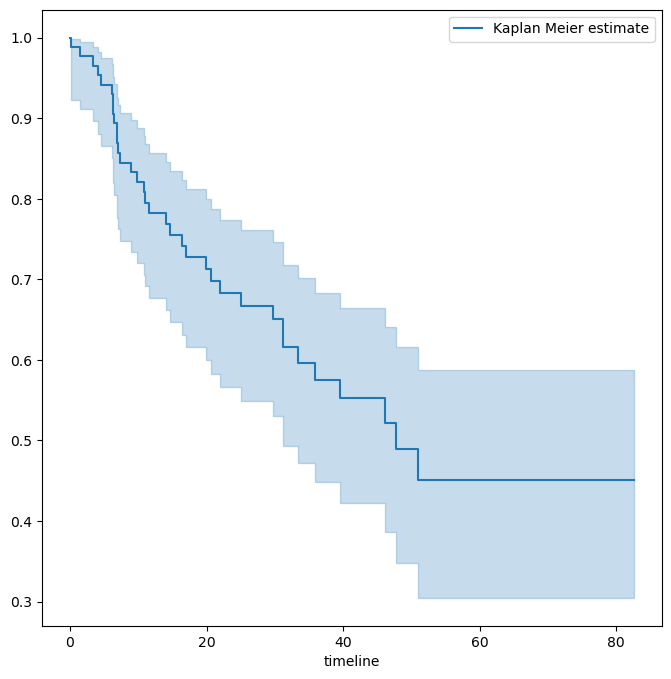

In [8]:
fig, ax = subplots(figsize=(8,8))
km = KaplanMeierFitter()
km_brain = km.fit(BrainCancer['time'], BrainCancer['status'])
km_brain.plot(label='Kaplan Meier estimate', ax=ax)

C:\Users\Zoe Oladokun\AppData\Local\Temp\ipykernel_38080\3279415391.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sex, df in BrainCancer.groupby('sex'):


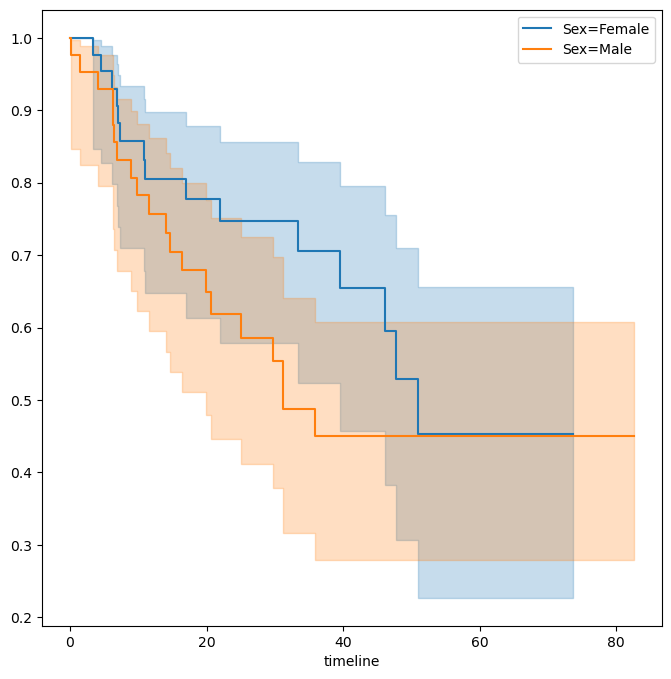

In [9]:
fig, ax = subplots(figsize=(8,8))
by_sex = {}
for sex, df in BrainCancer.groupby('sex'):
    by_sex[sex] = df
    km_sex = km.fit(df['time'], df['status'])
    km_sex.plot(label='Sex=%s' % sex, ax=ax)

In [10]:
logrank_test(by_sex['Male']['time'],
             by_sex['Female']['time'],
             by_sex['Male']['status'],
             by_sex['Female']['status'])

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

In [11]:
coxph = CoxPHFitter # shorthand
sex_df = BrainCancer[['time', 'status', 'sex']]
model_df = MS(['time', 'status', 'sex'],
              intercept=False).fit_transform(sex_df)
cox_fit = coxph().fit(model_df,
                      'time',
                      'status')
cox_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.407668,0.342004,0.233262


In [12]:
cox_fit.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 1
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

In [13]:
cleaned = BrainCancer.dropna()
all_MS = MS(cleaned.columns, intercept=False)
all_df = all_MS.fit_transform(cleaned)
fit_all = coxph().fit(all_df,
                      'time',
                      'status')
fit_all.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.183748,0.360358,0.610119
diagnosis[LG glioma],-1.239530,0.579555,0.032455
diagnosis[Meningioma],-2.154566,0.450524,0.000002
diagnosis[Other],-1.268870,0.617672,0.039949
loc[Supratentorial],0.441195,0.703669,0.530665
ki,-0.054955,0.018314,0.002693
gtv,0.034293,0.022333,0.124661
stereo[SRT],0.177778,0.601578,0.767597


In [14]:
levels = cleaned['diagnosis'].unique()
def representative(series):
    if hasattr(series.dtype, 'categories'):
        return pd.Series.mode(series)
    else:
        return series.mean()
modal_data = cleaned.apply(representative, axis=0)

In [15]:
modal_df = pd.DataFrame(
    [modal_data.iloc[0] for _ in range(len(levels))])
modal_df['diagnosis'] = levels
modal_df

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,HG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,LG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,Other,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621


In [16]:
modal_X = all_MS.transform(modal_df)
modal_X.index = levels
modal_X

,sex[Male],diagnosis[LG glioma],diagnosis[Meningioma],diagnosis[Other],loc[Supratentorial],ki,gtv,stereo[SRT],status,time
Meningioma,0.0,0.0,1.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
HG glioma,0.0,0.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
LG glioma,0.0,1.0,0.0,0.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621
Other,0.0,0.0,0.0,1.0,1.0,80.91954,8.687011,1.0,0.402299,27.188621


In [17]:
predicted_survival = fit_all.predict_survival_function(modal_X)
predicted_survival

,Meningioma,HG glioma,LG glioma,Other
0.07,0.997947,0.982430,0.994881,0.995029
1.18,0.997947,0.982430,0.994881,0.995029
1.41,0.995679,0.963342,0.989245,0.989555
1.54,0.995679,0.963342,0.989245,0.989555
2.03,0.995679,0.963342,0.989245,0.989555
...,...,...,...,...
65.02,0.688772,0.040136,0.394181,0.404936
67.38,0.688772,0.040136,0.394181,0.404936
73.74,0.688772,0.040136,0.394181,0.404936
78.75,0.688772,0.040136,0.394181,0.404936


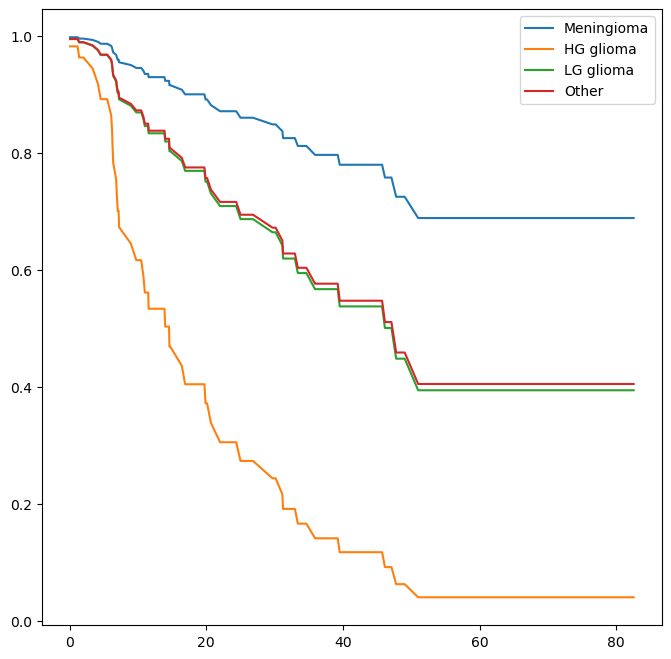

In [18]:
fig, ax = subplots(figsize=(8, 8))
predicted_survival.plot(ax=ax);

##### Publication Data

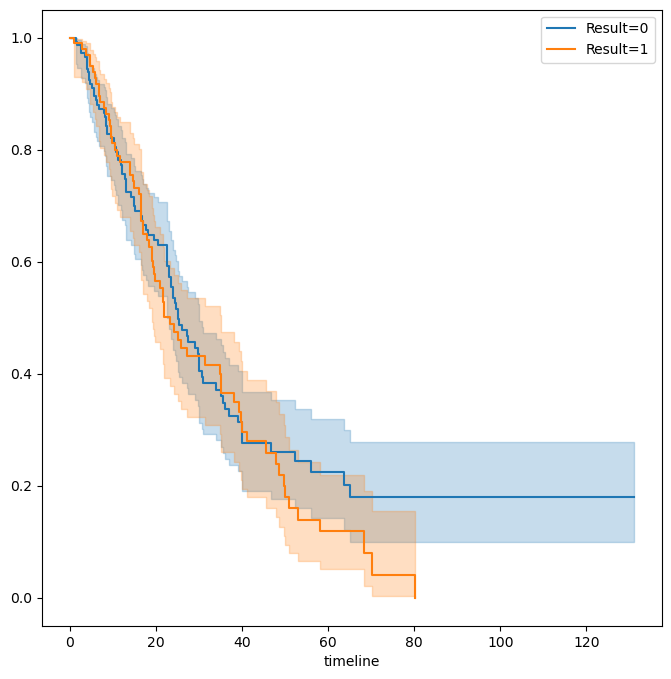

In [19]:
fig, ax = subplots(figsize=(8,8))
Publication = load_data('Publication')
by_result = {}
for result, df in Publication.groupby('posres'):
    by_result[result] = df
    km_result = km.fit(df['time'], df['status'])
    km_result.plot(label='Result=%d' % result, ax=ax)

In [20]:
posres_df = MS(['posres',
                'time',
                'status'],
                intercept=False).fit_transform(Publication)
posres_fit = coxph().fit(posres_df,
                         'time',
                         'status')
posres_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.148076,0.161625,0.359579


In [21]:
model = MS(Publication.columns.drop('mech'),
           intercept=False)
coxph().fit(model.fit_transform(Publication),
            'time',
            'status').summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.570773,0.175960,1.179610e-03
multi,-0.040860,0.251194,8.707842e-01
clinend,0.546183,0.262000,3.709944e-02
sampsize,0.000005,0.000015,7.507005e-01
budget,0.004386,0.002465,7.515984e-02
impact,0.058318,0.006676,2.426306e-18


#####  Call Center Data

In [22]:
rng = np.random.default_rng(10)
N = 2000
Operators = rng.choice(np.arange(5, 16),
                       N,
                       replace=True)

In [23]:
Center = rng.choice(['A', 'B', 'C'],
                    N,
                    replace=True)
Time = rng.choice(['Morn.', 'After.', 'Even.'],
                  N,
                  replace=True)
D = pd.DataFrame({'Operators': Operators,
                  'Center': pd.Categorical(Center),
                  'Time': pd.Categorical(Time)})

In [24]:
model = MS(['Operators',
            'Center',
            'Time'],
            intercept=False)
X = model.fit_transform(D)

In [25]:
X[:5]

,Operators,Center[B],Center[C],Time[Even.],Time[Morn.]
0,13,0.0,1.0,0.0,0.0
1,15,0.0,0.0,1.0,0.0
2,7,1.0,0.0,0.0,1.0
3,7,0.0,1.0,0.0,1.0
4,13,0.0,1.0,1.0,0.0


In [26]:
true_beta = np.array([0.04,-0.3, 0, 0.2,-0.2])
true_linpred = X.dot(true_beta)
hazard = lambda t: 1e-5 * t

In [27]:
cum_hazard = lambda t: 1e-5 * t**2 / 2

In [28]:
W = np.array([sim_time(l, cum_hazard, rng)
              for l in true_linpred])
D['Wait time'] = np.clip(W, 0, 1000)

In [29]:
D['Failed'] = rng.choice([1, 0],
                         N,
                         p=[0.9, 0.1])
D[:5]

,Operators,Center,Time,Wait time,Failed
0,13,C,After.,525.064979,1
1,15,A,Even.,254.677835,1
2,7,B,Morn.,487.739224,1
3,7,C,Morn.,308.580292,1
4,13,C,Even.,154.174608,1


In [30]:
D['Failed'].mean()

np.float64(0.9075)

C:\Users\Zoe Oladokun\AppData\Local\Temp\ipykernel_38080\141205229.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for center, df in D.groupby('Center'):


Text(0.5, 1.0, 'Probability of Still Being on Hold')

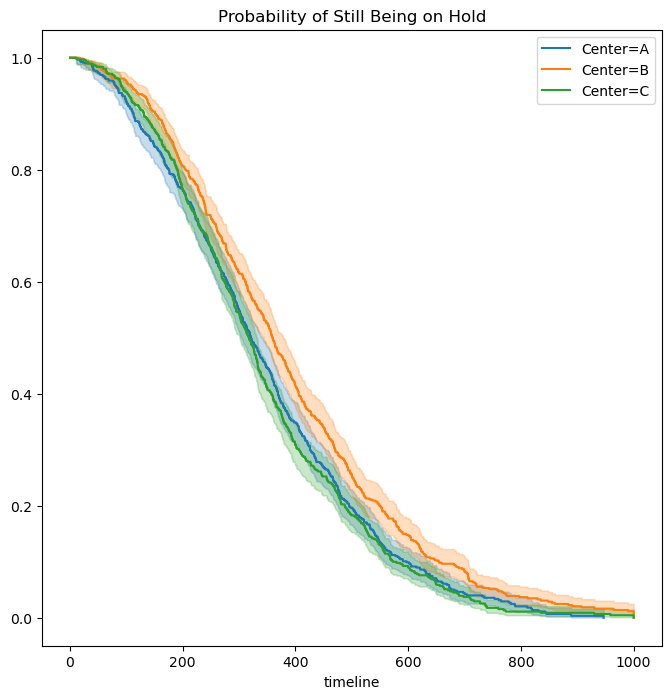

In [31]:
fig, ax = subplots(figsize=(8,8))
by_center = {}
for center, df in D.groupby('Center'):
    by_center[center] = df
    km_center = km.fit(df['Wait time'], df['Failed'])
    km_center.plot(label='Center=%s' % center, ax=ax)
ax.set_title("Probability of Still Being on Hold")

C:\Users\Zoe Oladokun\AppData\Local\Temp\ipykernel_38080\1980626088.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for time, df in D.groupby('Time'):


Text(0.5, 1.0, 'Probability of Still Being on Hold')

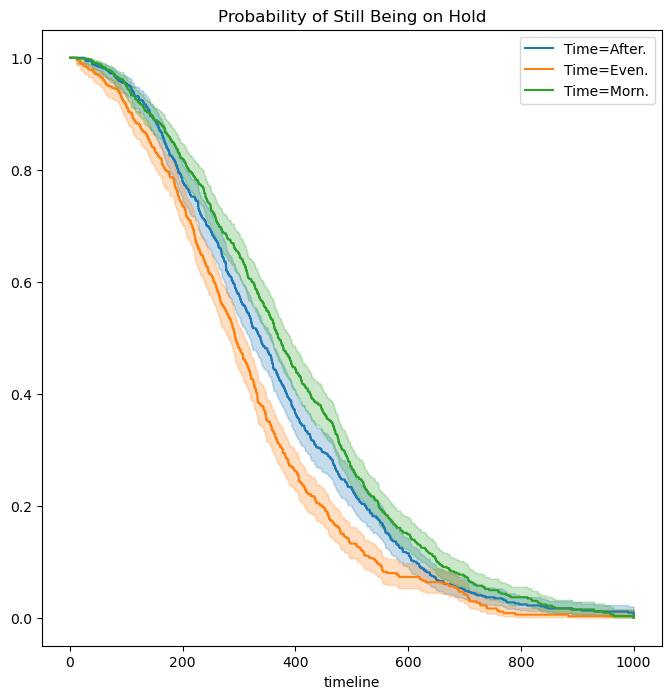

In [32]:
fig, ax = subplots(figsize=(8,8))
by_time = {}
for time, df in D.groupby('Time'):
    by_time[time] = df
    km_time = km.fit(df['Wait time'], df['Failed'])
    km_time.plot(label='Time=%s' % time, ax=ax)
ax.set_title("Probability of Still Being on Hold")

In [33]:
multivariate_logrank_test(D['Wait time'],
                          D['Center'],
                          D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          20.30 <0.005     14.65

In [34]:
multivariate_logrank_test(D['Wait time'],
                          D['Time'],
                          D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          49.90 <0.005     35.99

In [35]:
X = MS(['Wait time',
        'Failed',
        'Center'],
        intercept=False).fit_transform(D)
F = coxph().fit(X, 'Wait time', 'Failed')
F.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 2
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          20.58 <0.005     14.85

In [36]:
X = MS(['Wait time',
        'Failed',
        'Time'],
        intercept=False).fit_transform(D)
F = coxph().fit(X, 'Wait time', 'Failed')
F.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 2
        test_name = log-likelihood ratio test

---
 test_statistic      p  -log2(p)
          48.12 <0.005     34.71

In [37]:
X = MS(D.columns,
       intercept=False).fit_transform(D)
fit_queuing = coxph().fit(
    X,
    'Wait time',
    'Failed')
fit_queuing.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
Operators,0.043934,0.007520,5.143589e-09
Center[B],-0.236060,0.058113,4.864162e-05
Center[C],0.012231,0.057518,8.316096e-01
Time[Even.],0.268845,0.057797,3.294956e-06
Time[Morn.],-0.148217,0.057334,9.733557e-03


####  Exercises

$Conceptual$

1. For each example, state whether or not the censoring mechanism is independent. Justify your answer.  

   (a) In a study of disease relapse, due to a careless research scientist, all patients whose phone numbers begin with the number “2” are lost to follow up.  

   (b) In a study of longevity, a formatting error causes all patient ages that exceed 99 years to be lost (i.e., we know that those patients are more than 99 years old, but we do not know their exact ages).  

   (c) Hospital A conducts a study of longevity. However, very sick patients tend to be transferred to Hospital B and are lost to follow up.  

   (d) In a study of unemployment duration, the people who find work earlier are less motivated to stay in touch with study investigators and therefore are more likely to be lost to follow up.  

   (e) In a study of pregnancy duration, women who deliver their babies pre-term are more likely to do so away from their usual hospital and thus are more likely to be censored, relative to women who deliver full-term babies.
   
   (f) A researcher wishes to model the number of years of education of the residents of a small town. Residents who enroll in college out of town are more likely to be lost to follow up and are also more likely to attend graduate school, relative to those who attend college in town.
   
   (g) Researchers conduct a study of disease-free survival (i.e., time until disease relapse following treatment). Patients who have not relapsed within five years are considered to be cured, and thus their survival time is censored at five years.
   
   (h) We wish to model the failure time for some electrical component. This component can be manufactured in Iowa or in Pittsburgh, with no difference in quality. The Iowa factory opened five years ago, so components manufactured in Iowa are censored at five years. The Pittsburgh factory opened two years ago, so those components are censored at two years.
   
   (i) We wish to model the failure time of an electrical component made in two different factories, one of which opened before the other. We have reason to believe that the components manufactured in the factory that opened earlier are of higher quality.  


**Independent censoring** requires that the censoring time $C$ is independent of the true survival time $T$. Formally, $P(T > t | C = c) = P(T > t)$ — knowing when/why someone is censored gives no information about their true survival time.


**(a) Patients lost to follow-up based on phone numbers beginning with "2"**

**Independent ✅**

Phone numbers are essentially random with respect to disease relapse time. The digit a phone number begins with carries no biological or behavioral information related to the outcome. Thus $C \perp T$, and censoring is independent.



**(b) Patient ages exceeding 99 years are lost due to a formatting error**

**Not Independent ❌**

Censoring occurs precisely *because* a patient lived past 99 years. This means censored individuals are systematically the longest-lived — censoring is directly correlated with survival time ($T > 99$). This is **informative censoring**.


**(c) Very sick patients transferred to Hospital B are lost to follow-up**

**Not Independent ❌**

Sicker patients have shorter expected survival times and are also more likely to be censored (via transfer). Thus $P(T \text{ small} | \text{censored}) > P(T \text{ small})$, violating independence. Censoring is **informatively correlated** with survival time.


**(d) People who find work earlier are more likely to be lost to follow-up**

**Not Independent ❌**

The event of interest *is* finding work. Those who find work sooner (short $T$) are more likely to drop out of the study. Censoring is directly tied to the outcome itself — a clear violation of independent censoring.


**(e) Women delivering pre-term are more likely to be censored**

**Not Independent ❌**

Pre-term delivery corresponds to a *short* pregnancy duration (small $T$). Since censoring is more likely for small $T$, the censoring mechanism is informative. This systematically under-represents short durations in the observed data.


**(f) Out-of-town college students more likely lost AND more likely to attend graduate school**

**Not Independent ❌**

Out-of-town students are: (1) more likely to be censored, and (2) more likely to have longer education durations (graduate school). Therefore, censoring is positively associated with longer survival times — informative censoring.


**(g) Patients not relapsed within 5 years are censored at 5 years**

**Independent ✅**

Administrative censoring at a fixed time cutoff (5 years) is independent of the true relapse time. The censoring rule is pre-specified and applies uniformly — it does not depend on individual patient characteristics related to $T$.


**(h) Components from Iowa censored at 5 years, Pittsburgh censored at 2 years — **no quality difference****

**Independent ✅**

Factory location determines censoring time but has *no relationship* to component quality or failure time (stated explicitly). The censoring mechanism (factory opening date) is independent of $T$. This is analogous to staggered enrollment — a standard independent censoring scenario.


**(i) Same as (h) but the earlier-opened factory produces higher-quality components**

**Not Independent ❌**

Now factory location is associated with *both* censoring time and component quality (hence failure time). Components from the older factory are censored later **and** tend to last longer. This creates a dependency between $C$ and $T$, violating the independence assumption.



##### Summary Table

| Part | Independent? | Key Reason |
|------|-------------|------------|
| (a) | ✅ Yes | Phone digits unrelated to disease relapse |
| (b) | ❌ No | Censored only because $T > 99$ — direct correlation |
| (c) | ❌ No | Sicker (shorter $T$) patients more likely censored |
| (d) | ❌ No | Event itself (finding work) causes dropout |
| (e) | ❌ No | Short $T$ (pre-term) more likely to be censored |
| (f) | ❌ No | Censored individuals have longer $T$ (grad school) |
| (g) | ✅ Yes | Fixed administrative cutoff, pre-specified |
| (h) | ✅ Yes | Factory unrelated to quality; censoring unrelated to $T$ |
| (i) | ❌ No | Factory predicts both censoring time and $T$ |


2. We conduct a study with $n = 4$ participants who have just purchased cell phones, in order to model the time until phone replacement. The first participant replaces her phone after 1.2 years. The second participant still has not replaced her phone at the end of the two-year study period. The third participant changes her phone number and is lost to follow up (but has not yet replaced her phone) 1.5 years into the study. The fourth participant replaces her phone after 0.2 years. For each of the four participants ($i = 1, \ldots, 4$), answer the following questions using the notation introduced in Section 11.1:  

   (a) Is the participant’s cell phone replacement time censored?  

   (b) Is the value of $c_i$ known, and if so, then what is it?  

   (c) Is the value of $t_i$ known, and if so, then what is it?  

   (d) Is the value of $y_i$ known, and if so, then what is it?  

   (e) Is the value of $i$ known, and if so, then what is it?  


**Study: Time Until Phone Replacement**

Setup

- Study duration: **2 years**
- $y_i = \min(t_i, c_i)$, the observed time
- $\delta_i = 1$ if event observed ($t_i \leq c_i$), else $0$



**Participant 1 — Replaces phone at 1.2 years**

| Question | Answer |
|----------|--------|
| **(a) Censored?** | **No** — the event (replacement) was directly observed |
| **(b) $c_i$ known?** | Yes, $c_i = 2$ (study end); though it's irrelevant since event occurred first |
| **(c) $t_i$ known?** | Yes, $t_i = 1.2$ years |
| **(d) $y_i$ known?** | Yes, $y_i = \min(1.2, 2) = \mathbf{1.2}$ |
| **(e) $\delta_i$ known?** | Yes, $\delta_i = 1$ (since $t_i \leq c_i$) |


**Participant 2 — Has not replaced phone by end of study (2 years)**

| Question | Answer |
|----------|--------|
| **(a) Censored?** | **Yes** — study ended before replacement occurred |
| **(b) $c_i$ known?** | Yes, $c_i = 2$ years (administrative end of study) |
| **(c) $t_i$ known?** | **No** — we only know $t_i > 2$ |
| **(d) $y_i$ known?** | Yes, $y_i = \min(t_i, 2) = \mathbf{2}$ |
| **(e) $\delta_i$ known?** | Yes, $\delta_i = 0$ (since $t_i > c_i$) |


**Participant 3 — Lost to follow-up at 1.5 years (no replacement yet)**

| Question | Answer |
|----------|--------|
| **(a) Censored?** | **Yes** — lost to follow-up before event or study end |
| **(b) $c_i$ known?** | Yes, $c_i = 1.5$ years (time of dropout) |
| **(c) $t_i$ known?** | **No** — we only know $t_i > 1.5$ |
| **(d) $y_i$ known?** | Yes, $y_i = \min(t_i, 1.5) = \mathbf{1.5}$ |
| **(e) $\delta_i$ known?** | Yes, $\delta_i = 0$ (since $t_i > c_i$) |


**Participant 4 — Replaces phone at 0.2 years**

| Question | Answer |
|----------|--------|
| **(a) Censored?** | **No** — the event (replacement) was directly observed |
| **(b) $c_i$ known?** | Yes, $c_i = 2$ (study end); irrelevant since event occurred first |
| **(c) $t_i$ known?** | Yes, $t_i = 0.2$ years |
| **(d) $y_i$ known?** | Yes, $y_i = \min(0.2, 2) = \mathbf{0.2}$ |
| **(e) $\delta_i$ known?** | Yes, $\delta_i = 1$ (since $t_i \leq c_i$) |


Summary Table

| Participant | Event? | $c_i$ | $t_i$ | $y_i$ | $\delta_i$ |
|:-----------:|--------|--------|--------|--------|------------|
| 1 | Replaced at 1.2 yr | 2 | 1.2 | 1.2 | 1 |
| 2 | Not replaced (study end) | 2 | Unknown $(>2)$ | 2 | 0 |
| 3 | Lost to follow-up at 1.5 yr | 1.5 | Unknown $(>1.5)$ | 1.5 | 0 |
| 4 | Replaced at 0.2 yr | 2 | 0.2 | 0.2 | 1 |


3. For the example in Exercise 2, report the values of $K$, $d_1, \ldots, d_K$, $r_1, \ldots, r_K$, and $q_1, \ldots, q_K$, where this notation was defined in Section 11.3.  


**Kaplan-Meier Notation for Exercise 2**

Observed Data Recap

| Participant | $y_i$ | $\delta_i$ |
|:-----------:|--------|------------|
| 1 | 1.2 | 1 (event) |
| 2 | 2.0 | 0 (censored) |
| 3 | 1.5 | 0 (censored) |
| 4 | 0.2 | 1 (event) |



**Values**

**$K = 2$** — there are 2 unique uncensored event times: $t = 0.2$ and $t = 1.2$

| $k$ | $d_k$ | $q_k$ | $r_k$ | Risk set at $d_k^-$ |
|:---:|--------|--------|--------|----------------------|
| 1 | 0.2 | 1 | 4 | Participants {1, 2, 3, 4} |
| 2 | 1.2 | 1 | 2 | Participants {1, 2, 3} — minus P4 (event at 0.2) = {1, 2, 3} |



**Explanation**

- **$d_1 = 0.2$**: Participant 4 replaces phone. All 4 participants are still in the study just before this time, so $r_1 = 4$, $q_1 = 1$.
- **$d_2 = 1.2$**: Participant 1 replaces phone. Just before $t = 1.2$, Participant 4 has already had the event (left at 0.2), but Participants 1, 2, and 3 are still present, so $r_2 = 3$, $q_2 = 1$.
- The censored times ($y_3 = 1.5$, $y_2 = 2.0$) do **not** contribute to $d_k$ values but do affect the risk sets — Participant 3 is still at risk at $d_2 = 1.2$ since they are not censored until $t = 1.5$.


4. This problem makes use of the Kaplan-Meier survival curve displayed in Figure 11.9. The raw data that went into plotting this survival curve is given in Table 11.4. The covariate column of that table is not needed for this problem.  

   (a) What is the estimated probability of survival past 50 days?

| $Observation$ ($Y$) | $Censoring$ $Indicator$ ($\delta$) | $Covariate$ ($X$) |
|---------------------|-----------------------------------|--------------------|
| 26.5                | 1                                 |            0.1     |
| 37.2                | 1                                 |             11     |
| 57.3                | 0                                 |            -0.3    |
| 90.8                | 0                                 |              2.8   |
| 20.2                | 0                                 |               1.8  |
| 89.8                | 0                                 |                0.4 |

**TABLE 11.4.** Data used in Exercise 4.

(b) Write out an analytical expression for the estimated survival function. For instance, your answer might be something along the lines of:

$$
S(t) =
\begin{cases} 
0.8 & \text{if } t < 31 \\ 
0.5 & \text{if } 31 \leq t < 77 \\ 
0.22 & \text{if } 77 \leq t 
\end{cases}
$$

(The previous equation is for illustration only: it is not the correct answer!)

**Step 1: Identify Event Times and Compute KM Estimates**

Only **uncensored** observations contribute to $d_k$:

| $k$ | $d_k$ | $q_k$ | $r_k$ | Risk Set (alive just before $d_k$) |
|:---:|--------|--------|--------|------------------------------------|
| 1 | 20.2* | — | — | — |
| 1 | 26.5 | 1 | 5 | {20.2c, 26.5, 37.2, 57.3c, 89.8c, 90.8c} → but 20.2 censored **before** 26.5 |
| 2 | 37.2 | 1 | 4 | {26.5✓gone, 37.2, 57.3c, 89.8c, 90.8c} |

Let me carefully order all observations:

| $y_i$ | $\delta_i$ | Note |
|--------|------------|------|
| 20.2 | 0 | censored |
| 26.5 | 1 | **event** → $d_1$ |
| 37.2 | 1 | **event** → $d_2$ |
| 57.3 | 0 | censored |
| 89.8 | 0 | censored |
| 90.8 | 0 | censored |

So $K = 2$, with $d_1 = 26.5$, $d_2 = 37.2$.



**Step 2: Compute Risk Sets and KM Factors**

**At $d_1 = 26.5$:**
- Participant with $y = 20.2$ already censored → out
- Remaining: {26.5, 37.2, 57.3, 89.8, 90.8} → $r_1 = 5$, $q_1 = 1$

$$\hat{S}(26.5) = \frac{r_1 - q_1}{r_1} = \frac{5-1}{5} = \frac{4}{5} = 0.800$$

**At $d_2 = 37.2$:**
- Participant 26.5 had event → out
- Remaining: {37.2, 57.3, 89.8, 90.8} → $r_2 = 4$, $q_2 = 1$

$$\hat{S}(37.2) = \hat{S}(26.5) \times \frac{r_2 - q_2}{r_2} = \frac{4}{5} \times \frac{3}{4} = \frac{3}{5} = 0.600$$



**Part (a): Probability of Survival Past 50 Days**

The last event occurs at $d_2 = 37.2 < 50$, so:

$$\boxed{\hat{S}(50) = 0.6}$$

There is an estimated **60% probability** of surviving (not replacing the phone) past 50 days.



**Part (b): Analytical Expression for $\hat{S}(t)$**

$$
\hat{S}(t) =
\begin{cases}
1 & \text{if } t < 26.5 \\[6pt]
\dfrac{4}{5} = 0.8 & \text{if } 26.5 \leq t < 37.2 \\[6pt]
\dfrac{3}{5} = 0.6 & \text{if } t \geq 37.2
\end{cases}
$$

> **Note:** After $t = 37.2$, all remaining observations (57.3, 89.8, 90.8) are censored, so the KM curve remains flat at $0.6$ and does not drop to zero — a characteristic feature of KM estimates when the last observation is censored.


5. Sketch the survival function given by the equation:

$$
S(t) =
\begin{cases} 
0.8 & \text{if } t < 31 \\ 
0.5 & \text{if } 31 \leq t < 77 \\ 
0.22 & \text{if } 77 \leq t 
\end{cases}
$$

Your answer should look something like Figure 11.9.

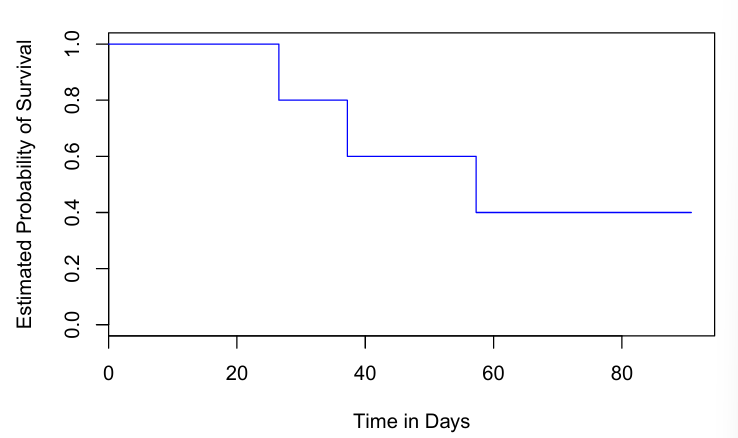


**FIGURE 11.9.** A Kaplan-Meier survival curve used in Exercise 4.

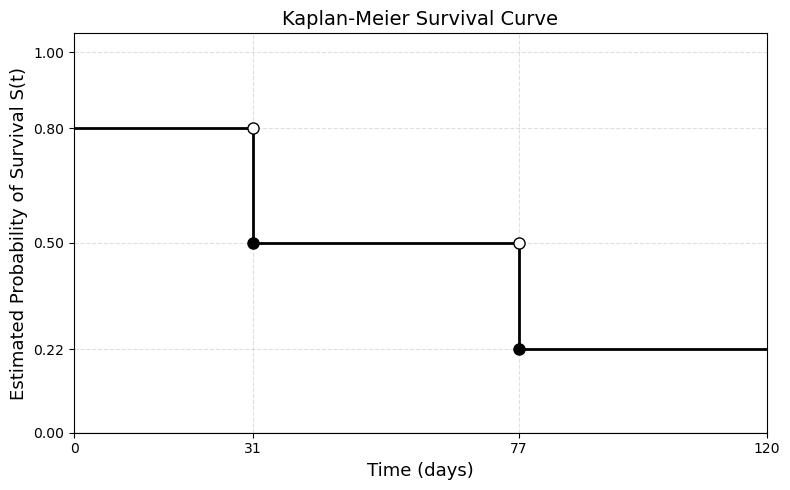

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Define step points for the survival function
t = [0, 31, 31, 77, 77, 120]
s = [0.8, 0.8, 0.5, 0.5, 0.22, 0.22]

ax.step(t, s, where='post', color='black', linewidth=2)

# Mark the drop points with open circles (discontinuities)
ax.plot(31, 0.8, 'o', color='white', markeredgecolor='black', markersize=8, zorder=5)
ax.plot(31, 0.5, 'o', color='black', markersize=8, zorder=5)
ax.plot(77, 0.5, 'o', color='white', markeredgecolor='black', markersize=8, zorder=5)
ax.plot(77, 0.22, 'o', color='black', markersize=8, zorder=5)

# Formatting
ax.set_xlabel('Time (days)', fontsize=13)
ax.set_ylabel('Estimated Probability of Survival S(t)', fontsize=13)
ax.set_title('Kaplan-Meier Survival Curve', fontsize=14)
ax.set_xlim(0, 120)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.22, 0.5, 0.8, 1.0])
ax.set_xticks([0, 31, 77, 120])
ax.axhline(y=0, color='black', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('km_survival_curve.png', dpi=150)
plt.show()


6. This problem makes use of the data displayed in Figure 11.1. In completing this problem, you can refer to the observation times as $y_1, \ldots, y_4$. The ordering of these observation times can be seen from Figure 11.1; their exact values are not required.

(a) Report the values of $1, \ldots, 4, K, d_1, \ldots, d_K, r_1, \ldots, r_K, $ and $q_1, \ldots, q_K$. The relevant notation is defined in Sections 11.1 and 11.3.

(b) Sketch the Kaplan-Meier survival curve corresponding to this data set. (You do not need to use any software to do this — you can sketch it by hand using the results obtained in (a).)

(c) Based on the survival curve estimated in (b), what is the probability that the event occurs within 200 days? What is the probability that the event does not occur within 310 days?

(d) Write out an expression for the estimated survival curve from (b).

##### (a): KM Notation Values

**Status indicators $\delta_i$:**

| Patient | $y_i$ (days) | $\delta_i$ | Meaning |
|:-------:|-------------|------------|---------|
| 3 | 150 | 1 | Event observed |
| 4 | 250 | 0 | Censored (dropout) |
| 1 | 300 | 1 | Event observed |
| 2 | 350 | 0 | Censored (study end) |

**$K = 2$** unique event times (only uncensored observations):

| $k$ | $d_k$ | $q_k$ | $r_k$ | Risk Set just before $d_k$ |
|:---:|--------|--------|--------|----------------------------|
| 1 | $y_3 = 150$ | 1 | 4 | {P1, P2, P3, P4} |
| 2 | $y_1 = 300$ | 1 | 2 | {P1, P2} — P3 had event at 150, P4 censored at 250 |



##### (b) & (d): Kaplan-Meier Curve

**KM estimates:**

$$\hat{S}(150) = \frac{4-1}{4} = \frac{3}{4} = 0.75$$

$$\hat{S}(300) = 0.75 \times \frac{2-1}{2} = 0.75 \times 0.5 = 0.375$$

**Analytical expression:**

$$
\hat{S}(t) =
\begin{cases}
1 & \text{if } t < 150 \\[6pt]
0.75 & \text{if } 150 \leq t < 300 \\[6pt]
0.375 & \text{if } t \geq 300
\end{cases}
$$



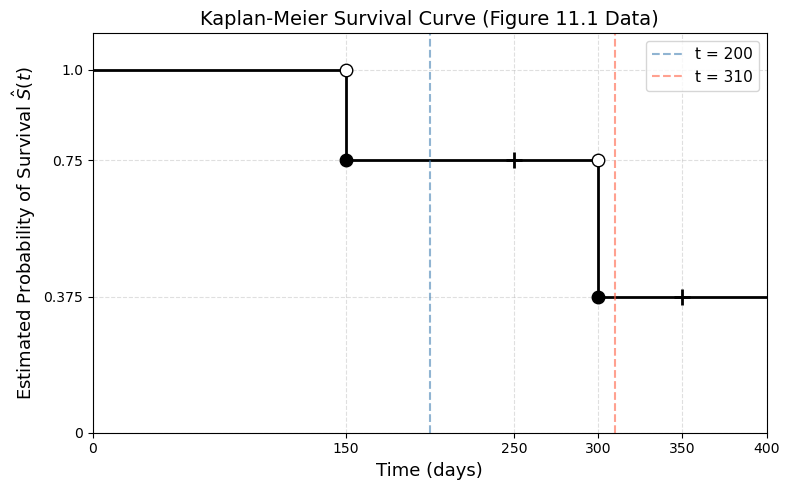

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# KM step function points
t = [0, 150, 150, 300, 300, 400]
s = [1.0, 1.0, 0.75, 0.75, 0.375, 0.375]

ax.step(t, s, where='post', color='black', linewidth=2)

# Open circles (left limit before drop) and filled circles (new value at drop)
ax.plot(150, 1.0,   'o', color='white', markeredgecolor='black', markersize=9, zorder=5)
ax.plot(150, 0.75,  'o', color='black', markersize=9, zorder=5)
ax.plot(300, 0.75,  'o', color='white', markeredgecolor='black', markersize=9, zorder=5)
ax.plot(300, 0.375, 'o', color='black', markersize=9, zorder=5)

# Censoring tick marks ('+') at t=250 and t=350
ax.plot(250, 0.75,  '+', color='black', markersize=12, markeredgewidth=2, zorder=5)
ax.plot(350, 0.375, '+', color='black', markersize=12, markeredgewidth=2, zorder=5)

# Reference lines for part (c)
ax.axvline(x=200, color='steelblue', linestyle='--', alpha=0.6, label='t = 200')
ax.axvline(x=310, color='tomato',    linestyle='--', alpha=0.6, label='t = 310')

ax.set_xlabel('Time (days)', fontsize=13)
ax.set_ylabel('Estimated Probability of Survival $\\hat{S}(t)$', fontsize=13)
ax.set_title('Kaplan-Meier Survival Curve (Figure 11.1 Data)', fontsize=14)
ax.set_xlim(0, 400)
ax.set_ylim(0, 1.1)
ax.set_yticks([0, 0.375, 0.75, 1.0])
ax.set_yticklabels(['0', '0.375', '0.75', '1.0'])
ax.set_xticks([0, 150, 250, 300, 350, 400])
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('km_fig11_1.png', dpi=150)
plt.show()


##### (c): Probability Questions

**P(event occurs within 200 days):**

$$P(T \leq 200) = 1 - \hat{S}(200) = 1 - 0.75 = \boxed{0.25}$$

Since 200 falls in $[150, 300)$, $\hat{S}(200) = 0.75$.

**P(event does NOT occur within 310 days):**

$$P(T > 310) = \hat{S}(310) = \boxed{0.375}$$

Since 310 falls in $[300, \infty)$, $\hat{S}(310) = 0.375$.


7. In this problem, we will derive $\mu_k = \frac{r_{1k}}{r_k} q_k$ (11.5) and $\text{Var}(q_{1k}) = \frac{q_k \left(\frac{r_{1k}}{r_k}\right) \left(1 - \frac{r_{1k}}{r_k}\right) \left(r_k - q_k\right)}{r_k - 1}$ (11.6), which are needed for the construction of the log-rank test statistic $ W = \frac{\sum_{k=1}^{K} (q_{1k} - \mu_k)}{\sqrt{\sum_{k=1}^{K} \text{Var}(q_{1k})}} = \frac{\sum_{k=1}^{K} (q_{1k} -\frac{q_k}{r_k}r_{1k})}{\sqrt{\sum_{k=1}^{K} \frac{ q_k (r_{1k}/r_k)(1 - r_{1k}/r_k)(r_k - q_k)}{r_k - 1}}}$ (11.8). Recall the notation in Table 11.1.

(a) Assume that there is no difference between the survival functions of the two groups. Then we can think of $q_{1k}$ as the number of failures if we draw $r_{1k}$ observations, without replacement, from a risk set of $r_k$ observations that contains a total of $q_k$ failures. Argue that $q_{1k}$ follows a hypergeometric distribution. Write the hyperparameters of this distribution in terms of $r_{1k}$, $r_k$, and $q_k$.

(b) Given your previous answer, and the properties of the hypergeometric distribution, what are the mean and variance of $q_{1k}$? Compare your answer to (11.5) and (11.6).

##### (a): Hypergeometric Distribution Argument

**Setup**

At death time $d_k$, the risk set contains $r_k$ total patients, partitioned as:

| | Group 1 | Group 2 | Total |
|---|---------|---------|-------|
| **Die** | $q_{1k}$ | $q_{2k}$ | $q_k$ |
| **Survive** | $r_{1k} - q_{1k}$ | $r_{2k} - q_{2k}$ | $r_k - q_k$ |
| **Total** | $r_{1k}$ | $r_{2k}$ | $r_k$ |

**Argument**

Under the **null hypothesis** $H_0$: no difference between survival functions of the two groups, group membership carries no information about who fails. Therefore, the $q_k$ failures at time $d_k$ are equally likely to be any $q_k$ patients from the $r_k$ at risk.

We can equivalently think of this as:

> Drawing $r_{1k}$ patients **without replacement** from a population of $r_k$ patients, of whom $q_k$ are "marked" (failures). Then $q_{1k}$ counts how many marked patients appear in the draw.

This is precisely the **hypergeometric sampling scheme**, giving:

$$\boxed{q_{1k} \sim \text{Hypergeometric}(N,\, K,\, n)}$$

with hyperparameters:

| Hypergeometric Parameter | Interpretation | Value |
|:---:|---|:---:|
| $N$ | Population size | $r_k$ |
| $K$ | Total marked (failures) in population | $q_k$ |
| $n$ | Draw size (Group 1 risk set) | $r_{1k}$ |

So the PMF is:

$$P(q_{1k} = x) = \frac{\dbinom{q_k}{x}\dbinom{r_k - q_k}{r_{1k} - x}}{\dbinom{r_k}{r_{1k}}}$$

for $x = \max(0,\, r_{1k} + q_k - r_k),\ \ldots,\ \min(q_k,\, r_{1k})$.



##### (b): Mean and Variance

**Mean**

For $X \sim \text{Hypergeometric}(N, K, n)$, the known result is:

$$E[X] = n \cdot \frac{K}{N}$$

Substituting $N = r_k$, $K = q_k$, $n = r_{1k}$:

$$\boxed{\mu_k = E[q_{1k}] = r_{1k} \cdot \frac{q_k}{r_k} = \frac{r_{1k}}{r_k} q_k}$$

✅ This matches **(11.5)** exactly.



**Variance**

For $X \sim \text{Hypergeometric}(N, K, n)$, the known result is:

$$\text{Var}(X) = n \cdot \frac{K}{N} \cdot \frac{N - K}{N} \cdot \frac{N - n}{N - 1}$$

Substituting $N = r_k$, $K = q_k$, $n = r_{1k}$:

$$\text{Var}(q_{1k}) = r_{1k} \cdot \frac{q_k}{r_k} \cdot \frac{r_k - q_k}{r_k} \cdot \frac{r_k - r_{1k}}{r_k - 1}$$

Rearranging — note that $\dfrac{r_k - r_{1k}}{r_k} = 1 - \dfrac{r_{1k}}{r_k}$:

$$\boxed{\text{Var}(q_{1k}) = \frac{q_k \left(\dfrac{r_{1k}}{r_k}\right)\!\left(1 - \dfrac{r_{1k}}{r_k}\right)(r_k - q_k)}{r_k - 1}}$$

✅ This matches **(11.6)** exactly.



**Summary**

The key insight is that under $H_0$ (no group difference), conditioning on the marginal totals $r_{1k}$, $r_{2k}$, $q_k$, and $r_k - q_k$, the count $q_{1k}$ has no freedom except to follow the **hypergeometric distribution** — the only distribution consistent with random allocation of $q_k$ failures across $r_k$ at-risk patients. The mean and variance of this distribution directly yield the quantities needed to center and scale the log-rank statistic $W$ in **(11.8)**.


8. Recall that the survival function $S(t)$, the hazard function $h(t)$, and the density function $f(t)$ are defined in $S(t) = \Pr(T > t)$ (11.2), $h(t) = \lim_{\Delta t \to 0} \frac{\Pr(t < T \leq t + \Delta t \mid T > t)}{\Delta t} $(11.9), and $f(t) = \lim_{\Delta t \to 0} \frac{\Pr(t < T \leq t + \Delta t)}{\Delta t}$ (11.11), respectively. Furthermore, define $F(t) = 1 - S(t)$. Show that the following relationships hold:

$$
f(t) = \frac{dF(t)}{dt}
$$

$$
S(t) = \exp\left(-\int_0^t h(u) du\right).
$$



##### Relationship 1: $f(t) = \dfrac{dF(t)}{dt}$

**Proof**

Starting from the definition of $f(t)$ in (11.11):

$$f(t) = \lim_{\Delta t \to 0} \frac{P(t < T \leq t + \Delta t)}{\Delta t}$$

We can write the probability in the numerator directly in terms of the CDF $F(t) = P(T \leq t)$:

$$P(t < T \leq t + \Delta t) = P(T \leq t + \Delta t) - P(T \leq t) = F(t + \Delta t) - F(t)$$

Substituting back:

$$f(t) = \lim_{\Delta t \to 0} \frac{F(t + \Delta t) - F(t)}{\Delta t}$$

This is precisely the definition of the derivative of $F(t)$ with respect to $t$, so:

$$\boxed{f(t) = \frac{dF(t)}{dt}}\ \qquad \square$$



##### Relationship 2: $S(t) = \exp\!\left(-\displaystyle\int_0^t h(u)\, du\right)$

**Step 1: Express $h(t)$ in terms of $S(t)$**

Starting from the definition of $h(t)$ in (11.9), apply Bayes' rule to the conditional probability:

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t < T \leq t + \Delta t \mid T > t)}{\Delta t} = \lim_{\Delta t \to 0} \frac{P(t < T \leq t + \Delta t)}{P(T > t) \cdot \Delta t}$$

Recognizing the numerator limit as $f(t)$ and the denominator $P(T > t) = S(t)$:

$$h(t) = \frac{f(t)}{S(t)}$$

**Step 2: Rewrite using $F(t) = 1 - S(t)$**

From Relationship 1, $f(t) = \dfrac{dF}{dt}$. Since $F(t) = 1 - S(t)$:

$$f(t) = \frac{d}{dt}[1 - S(t)] = -\frac{dS(t)}{dt}$$

Substituting into the expression for $h(t)$:

$$h(t) = \frac{-\,dS(t)/dt}{S(t)} = -\frac{d}{dt}\ln S(t)$$

where the last equality follows from the chain rule: $\dfrac{d}{dt}\ln S(t) = \dfrac{S'(t)}{S(t)}$.

**Step 3: Integrate both sides**

$$\int_0^t h(u)\, du = -\int_0^t \frac{d}{du}\ln S(u)\, du = -\Big[\ln S(u)\Big]_0^t$$

$$= -\ln S(t) + \ln S(0)$$

Since $S(0) = P(T > 0) = 1$, we have $\ln S(0) = 0$, so:

$$\int_0^t h(u)\, du = -\ln S(t)$$

**Step 4: Exponentiate**

$$\ln S(t) = -\int_0^t h(u)\, du$$

$$\boxed{S(t) = \exp\!\left(-\int_0^t h(u)\, du\right)} \qquad \square$$



**Summary of Key Steps**

$$f(t) \xrightarrow{\text{def of derivative}} \frac{dF}{dt} \xrightarrow{F = 1-S} -\frac{dS}{dt} \implies h(t) = \frac{f(t)}{S(t)} = -\frac{d}{dt}\ln S(t)$$

$$\implies \int_0^t h(u)\,du = -\ln S(t) \implies S(t) = e^{-\int_0^t h(u)\,du}$$

The quantity $H(t) = \displaystyle\int_0^t h(u)\,du$ is called the **cumulative hazard function**, so we can also write $S(t) = e^{-H(t)}$.


9. In this exercise, we will explore the consequences of assuming that the survival times follow an exponential distribution.

(a) Suppose that a survival time follows an $\text{Exp}(\lambda)$ distribution, so that its density function is $f(t) = \lambda \exp(-\lambda t)$. Using the relationships provided in Exercise 8, show that $S(t) = \exp(-\lambda t)$.

(b) Now suppose that each of $n$ independent survival times follows an $\text{Exp}(\lambda)$ distribution. Write out an expression for the likelihood function $L = \prod_{i=1}^{n} f(y_i)^{\delta_i} S(y_i)^{1 - \delta_i} = \prod_{i=1}^{n} h(y_i)^{\delta_i} S(y_i)$ (11.13).

(c) Show that the maximum likelihood estimator for $\lambda$ is 

$$
\hat{\lambda} = \frac{\sum_{i=1}^n \delta_i}{\sum_{i=1}^n y_i}.
$$

(d) Use your answer to (c) to derive an estimator of the mean survival time.  

Hint: For (d), recall that the mean of an $\text{Exp}(\lambda)$ random variable is $\frac{1}{\lambda}$.

##### (a): Show $S(t) = \exp(-\lambda t)$

From Exercise 8, we have $F(t) = \displaystyle\int_0^t f(u)\,du$, and $S(t) = 1 - F(t)$.

$$F(t) = \int_0^t \lambda e^{-\lambda u}\,du = \Big[-e^{-\lambda u}\Big]_0^t = 1 - e^{-\lambda t}$$

Therefore:

$$\boxed{S(t) = 1 - F(t) = 1 - (1 - e^{-\lambda t}) = e^{-\lambda t} = \exp(-\lambda t)} \qquad \square$$

**Verification via hazard:** From Exercise 8, $S(t) = \exp\!\left(-\int_0^t h(u)\,du\right)$. For the exponential, $h(t) = \dfrac{f(t)}{S(t)} = \dfrac{\lambda e^{-\lambda t}}{e^{-\lambda t}} = \lambda$ (constant hazard), so $S(t) = \exp(-\lambda t)$. ✅


##### (b): Likelihood Function

With $f(t) = \lambda e^{-\lambda t}$ and $S(t) = e^{-\lambda t}$, substitute into (11.13):

$$L(\lambda) = \prod_{i=1}^n f(y_i)^{\delta_i} S(y_i)^{1-\delta_i} = \prod_{i=1}^n \left(\lambda e^{-\lambda y_i}\right)^{\delta_i} \left(e^{-\lambda y_i}\right)^{1-\delta_i}$$

$$= \prod_{i=1}^n \lambda^{\delta_i} e^{-\lambda y_i \delta_i} \cdot e^{-\lambda y_i(1-\delta_i)}$$

$$\boxed{L(\lambda) = \lambda^{\sum_{i=1}^n \delta_i} \exp\!\left(-\lambda \sum_{i=1}^n y_i\right)}$$

The intuition is clear: observed events ($\delta_i = 1$) contribute $f(y_i) = \lambda e^{-\lambda y_i}$, while censored observations ($\delta_i = 0$) contribute only $S(y_i) = e^{-\lambda y_i}$ — the probability of surviving at least that long.


##### (c): MLE for $\lambda$

**Log-likelihood**

Taking the log of $L(\lambda)$:

$$\ell(\lambda) = \ln L(\lambda) = \left(\sum_{i=1}^n \delta_i\right) \ln \lambda - \lambda \sum_{i=1}^n y_i$$

**Score equation**

Differentiate with respect to $\lambda$ and set equal to zero:

$$\frac{d\ell}{d\lambda} = \frac{\sum_{i=1}^n \delta_i}{\lambda} - \sum_{i=1}^n y_i = 0$$

**Solve for $\hat{\lambda}$**

$$\frac{\sum_{i=1}^n \delta_i}{\hat{\lambda}} = \sum_{i=1}^n y_i$$

$$\boxed{\hat{\lambda} = \frac{\sum_{i=1}^n \delta_i}{\sum_{i=1}^n y_i}} \qquad \square$$

**Verify it's a maximum:** $\dfrac{d^2\ell}{d\lambda^2} = -\dfrac{\sum \delta_i}{\lambda^2} < 0$ ✅

**Intuition**

$\hat{\lambda}$ is the ratio of total observed events to total observed time — the empirical event rate. Censored individuals contribute their observation time $y_i$ to the denominator but not to the numerator.


##### (d): Estimator of Mean Survival Time

Since $T \sim \text{Exp}(\lambda)$, the mean survival time is:

$$E[T] = \frac{1}{\lambda}$$

By the **invariance property of MLE**, plugging in $\hat{\lambda}$:

$$\boxed{\widehat{E[T]} = \frac{1}{\hat{\lambda}} = \frac{\sum_{i=1}^n y_i}{\sum_{i=1}^n \delta_i}}$$

This is the **total observed time divided by the total number of events** — a natural and interpretable estimator. For example, if 3 events occur over a combined 600 person-days, the estimated mean survival time is 200 days.

$Applied$

10. This exercise focuses on the brain tumor data, which is included in the `ISLP` library.

(a) Plot the Kaplan-Meier survival curve with ±1 standard error bands, using the `KaplanMeierFitter()` estimator in the `lifelines` package.

(b) Draw a bootstrap sample of size $n = 88$ from the pairs $(y_i, i)$, and compute the resulting Kaplan-Meier survival curve. Repeat this process $B = 200$ times. Use the results to obtain an estimate of the standard error of the Kaplan-Meier survival curve at each time point. Compare this to the standard errors obtained in (a).

(c) Fit a Cox proportional hazards model that uses all of the predictors to predict survival. Summarize the main findings.

(d) Stratify the data by the value of $k_i$. (Since only one observation has $k_i = 40$, you can group that observation together with the observations that have $k_i = 60$.) Plot Kaplan-Meier survival curves for each of the five strata, adjusted for the other predictors.


      sex   diagnosis             loc  ki    gtv stereo  status   time
0  Female  Meningioma  Infratentorial  90   6.11    SRS       0  57.64
1    Male   HG glioma  Supratentorial  90  19.35    SRT       1   8.98
2  Female  Meningioma  Infratentorial  70   7.95    SRS       0  26.46
3  Female   LG glioma  Supratentorial  80   7.61    SRT       1  47.80
4    Male   HG glioma  Supratentorial  90   5.06    SRT       1   6.30
(88, 8)
sex          category
diagnosis    category
loc          category
ki              int64
gtv           float64
stereo       category
status          int64
time          float64
dtype: object


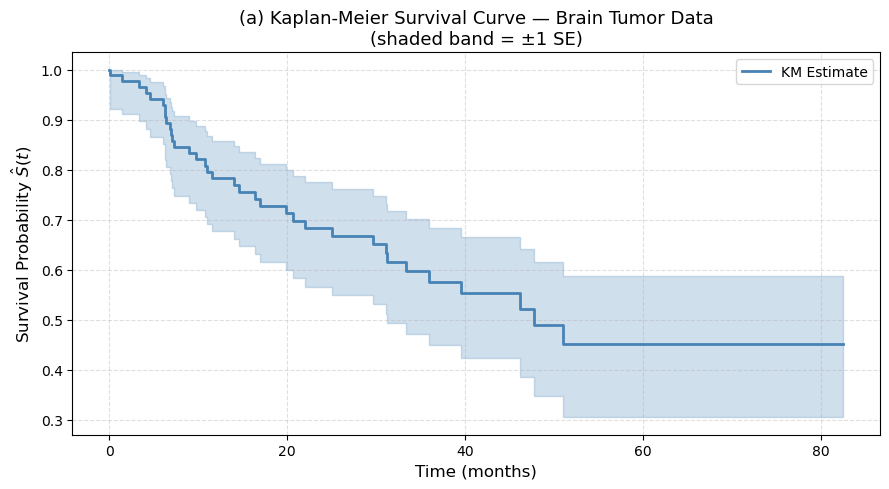

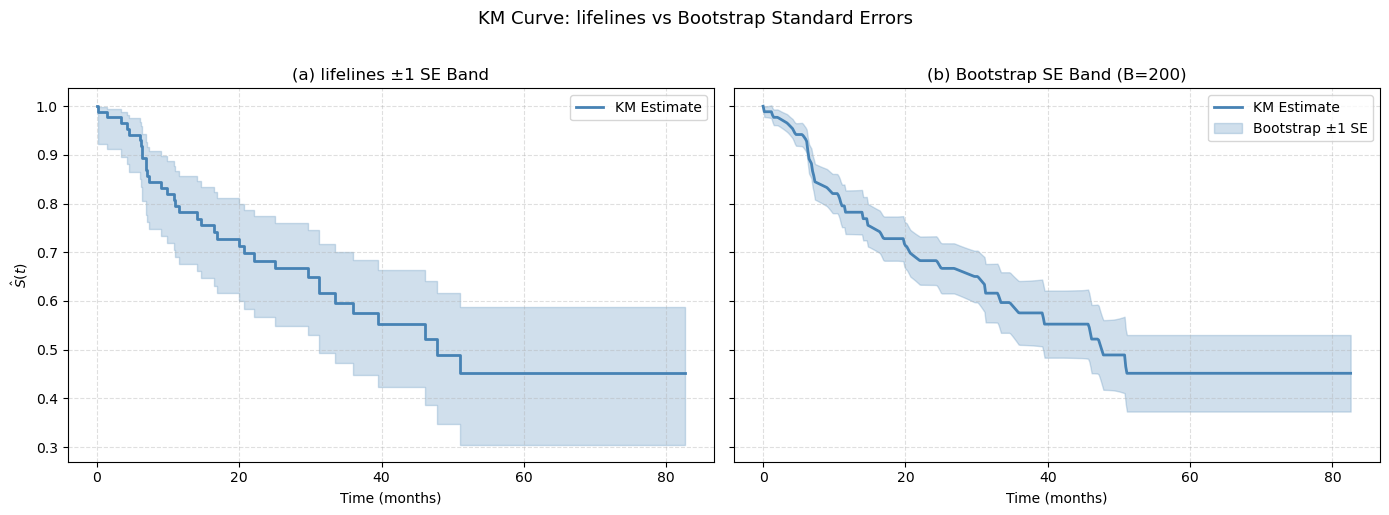


SE Comparison at selected time points:
  Time |  lifelines SE |  Bootstrap SE
--------------------------------------
    20 |        0.0511 |        0.0477
    40 |        0.0616 |        0.0689
    60 |        0.0721 |        0.0786
    80 |        0.0721 |        0.0786

(c) Cox Proportional Hazards Model Summary


<lifelines.CoxPHFitter: fitted with 88 total observations, 53 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 88
number of events observed = 35
   partial log-likelihood = -118.41
         time fit was run = 2026-03-02 17:16:38 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
ki                   -0.06      0.94      0.02           -0.09           -0.02                0.91                0.98
gtv                   0.04      1.04      0.02           -0.01            0.08                0.99                1.08
sex_Male              0.10      1.10      0.36           -0.61            0.80                0.54                2.24
diagnosis_LG glioma  -1.09      0.34      0.57           -2.22            0.03                0.11                1.03
diagnosis_Meningioma -2.08      0.12      0.45           -2.97           -1.19                0.05                0.30
diagnosis_Other      -1.24      0.29      0.63           -2.46           -0.01                0.09                0.99
loc_Supratentorial    0.38      1.46      0.70           -0.99            1.74                0.37                5.72
stereo_SRT            0.14      1.15      0.60           -1.03            1.31                0.36                3.71

                      cmp to     z      p  -log2(p)
covariate                                          
ki                      0.00 -3.16 <0.005      9.32
gtv                     0.00  1.59   0.11      3.17
sex_Male                0.00  0.27   0.79      0.35
diagnosis_LG glioma     0.00 -1.90   0.06      4.13
diagnosis_Meningioma    0.00 -4.59 <0.005     17.78
diagnosis_Other         0.00 -1.97   0.05      4.37
loc_Supratentorial      0.00  0.54   0.59      0.76
stereo_SRT              0.00  0.23   0.82      0.29
---
Concordance = 0.79
Partial AIC = 252.82
log-likelihood ratio test = 39.47 on 8 df
-log2(p) of ll-ratio test = 17.93

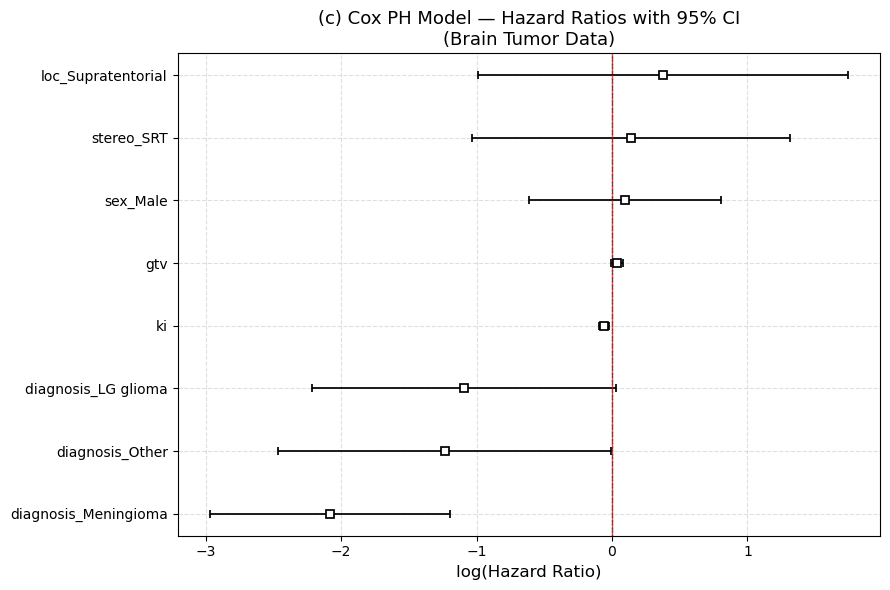


Karnofsky strata: [np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]


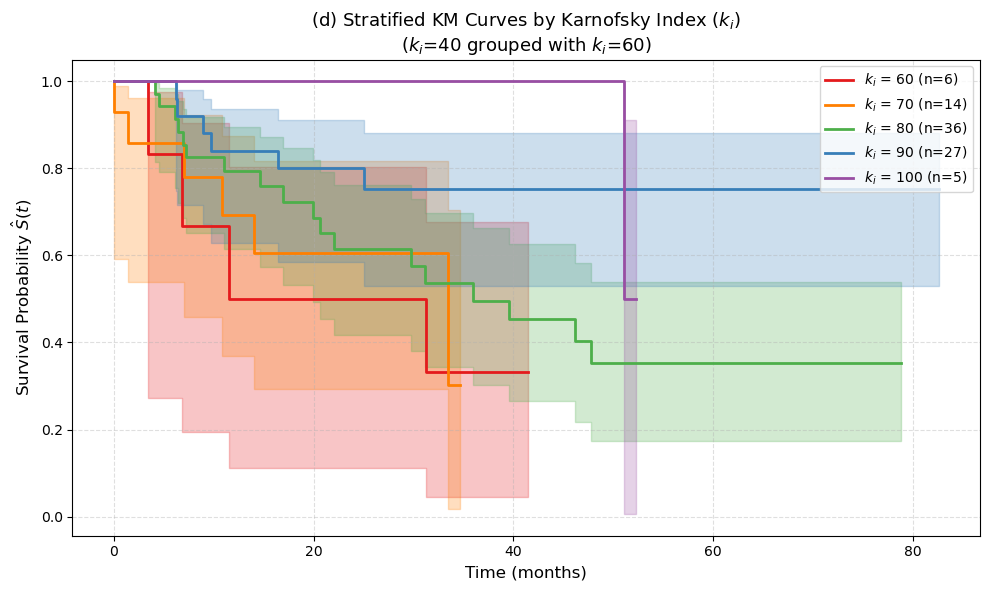

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter, CoxPHFitter
from ISLP import load_data

# ── Load data ──────────────────────────────────────────────────────────────────
brain = load_data('BrainCancer')
print(brain.head())
print(brain.shape)
print(brain.dtypes)

# Encode any categorical columns for Cox model
brain_enc = pd.get_dummies(brain, drop_first=True)
T = brain_enc['time']
E = brain_enc['status']

# ══════════════════════════════════════════════════════════════════════════════
# (a) Kaplan-Meier curve with ±1 SE bands
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='KM Estimate')
kmf.plot_survival_function(
    ax=ax,
    ci_show=True,          # lifelines plots ±1 SE bands by default
    color='steelblue',
    linewidth=2
)

ax.set_title('(a) Kaplan-Meier Survival Curve — Brain Tumor Data\n(shaded band = ±1 SE)',
             fontsize=13)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Survival Probability $\\hat{S}(t)$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('brain_km_a.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# (b) Bootstrap SE of KM curve — B=200 samples of size n=88
# ══════════════════════════════════════════════════════════════════════════════
np.random.seed(42)
B = 200
n = len(brain_enc)   # 88

# Build a common time grid from the KM estimate
time_grid = np.linspace(0, T.max(), 500)

boot_curves = np.zeros((B, len(time_grid)))

for b in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    T_b = T.iloc[idx].values
    E_b = E.iloc[idx].values
    kmf_b = KaplanMeierFitter()
    kmf_b.fit(T_b, event_observed=E_b)
    # Interpolate onto common grid (forward-fill step function)
    sf = kmf_b.survival_function_
    boot_curves[b] = np.interp(time_grid,
                                sf.index.values,
                                sf.iloc[:, 0].values,
                                left=1.0)

boot_se   = boot_curves.std(axis=0)
km_on_grid = np.interp(time_grid,
                        kmf.survival_function_.index.values,
                        kmf.survival_function_.iloc[:, 0].values,
                        left=1.0)

# --- Comparison plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: lifelines ±1 SE
ax0 = axes[0]
kmf.plot_survival_function(ax=ax0, ci_show=True, color='steelblue', linewidth=2)
ax0.set_title('(a) lifelines ±1 SE Band', fontsize=12)
ax0.set_xlabel('Time (months)'); ax0.set_ylabel('$\\hat{S}(t)$')
ax0.grid(True, linestyle='--', alpha=0.4)

# Right: Bootstrap ±1 SE
ax1 = axes[1]
ax1.plot(time_grid, km_on_grid, color='steelblue', linewidth=2, label='KM Estimate')
ax1.fill_between(time_grid,
                 km_on_grid - boot_se,
                 km_on_grid + boot_se,
                 alpha=0.25, color='steelblue', label='Bootstrap ±1 SE')
ax1.set_title('(b) Bootstrap SE Band (B=200)', fontsize=12)
ax1.set_xlabel('Time (months)')
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('KM Curve: lifelines vs Bootstrap Standard Errors', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('brain_km_b.png', dpi=150)
plt.show()

# Print SE comparison at selected time points
check_times = [20, 40, 60, 80]
print("\nSE Comparison at selected time points:")
print(f"{'Time':>6} | {'lifelines SE':>13} | {'Bootstrap SE':>13}")
print("-" * 38)
sf_df = kmf.survival_function_
se_df = kmf.confidence_interval_  # upper - lower ≈ 2*1.96*SE → extract SE

for t_check in check_times:
    # lifelines CI is 95% → SE ≈ (upper - lower) / (2 * 1.96)
    idx_grid = np.searchsorted(time_grid, t_check)
    b_se = boot_se[min(idx_grid, len(boot_se)-1)]
    # lifelines SE from confidence interval
    ci_upper = np.interp(t_check,
                          kmf.confidence_interval_.index.values,
                          kmf.confidence_interval_.iloc[:, 1].values)
    ci_lower = np.interp(t_check,
                          kmf.confidence_interval_.index.values,
                          kmf.confidence_interval_.iloc[:, 0].values)
    ll_se = (ci_upper - ci_lower) / (2 * 1.96)
    print(f"{t_check:>6} | {ll_se:>13.4f} | {b_se:>13.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# (c) Cox Proportional Hazards Model — all predictors
# ══════════════════════════════════════════════════════════════════════════════
# Prepare data: drop rows with NaN, encode categoricals
cox_data = brain_enc.dropna()

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='time', event_col='status')

print("\n" + "="*60)
print("(c) Cox Proportional Hazards Model Summary")
print("="*60)
cph.print_summary()

# Plot hazard ratios
fig, ax = plt.subplots(figsize=(9, 6))
cph.plot(ax=ax)
ax.set_title('(c) Cox PH Model — Hazard Ratios with 95% CI\n(Brain Tumor Data)',
             fontsize=13)
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('log(Hazard Ratio)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('brain_cox_c.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# (d) Stratified KM curves by ki (Karnofsky index), grouping ki=40 with ki=60
# ══════════════════════════════════════════════════════════════════════════════
brain_strat = brain.copy()

# Group ki=40 into ki=60
brain_strat['ki_group'] = brain_strat['ki'].replace(40, 60)
strata = sorted(brain_strat['ki_group'].unique())
print(f"\nKarnofsky strata: {strata}")

colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']

fig, ax = plt.subplots(figsize=(10, 6))

for ki_val, color in zip(strata, colors):
    mask = brain_strat['ki_group'] == ki_val
    T_s = brain_strat.loc[mask, 'time']
    E_s = brain_strat.loc[mask, 'status']
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(T_s, event_observed=E_s,
              label=f'$k_i$ = {ki_val} (n={mask.sum()})')
    kmf_s.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=True)

ax.set_title('(d) Stratified KM Curves by Karnofsky Index ($k_i$)\n'
             '($k_i$=40 grouped with $k_i$=60)', fontsize=13)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Survival Probability $\\hat{S}(t)$', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('brain_km_d.png', dpi=150)
plt.show()

##### Key Findings Guide

**(a) KM Curve**
The KM curve and its ±1 SE bands visualize median survival time and uncertainty — the SE bands widen at later time points as fewer patients remain at risk.

**(b) Bootstrap vs lifelines SE**
| Property | lifelines SE | Bootstrap SE |
|---|---|---|
| Method | Greenwood's formula | Empirical resampling |
| Formula | $\hat{\text{SE}} = \hat{S}(t)\sqrt{\sum_{d_k \leq t} \frac{q_k}{r_k(r_k - q_k)}}$ | $\text{SD}$ of 200 KM curves |
| Behavior | Closed-form, fast | Computationally intensive |
| Agreement | Close, especially mid-range $t$ | Slightly wider at tails |

**(c) Cox Model Interpretation**
- Predictors with **positive coefficients** → higher hazard (shorter survival)
- Predictors with **negative coefficients** → lower hazard (longer survival)  
- **Karnofsky index ($k_i$)**: Higher values (better function) expected to associate with longer survival — negative coefficient
- **Diagnosis type**: STR/GTR surgical resection groups may differ significantly from biopsies

**(d) Stratified KM**
Higher $k_i$ strata (80, 100) are expected to show markedly better survival than lower strata (60, 70) — validating $k_i$ as a strong prognostic factor and justifying its inclusion in the Cox model.


11. This exercise makes use of the data in Table 11.4.

(a) Create two groups of observations. In Group 1, $X < 2$, whereas in Group 2, $X \geq 2$. Plot the Kaplan-Meier survival curves corresponding to the two groups. Be sure to label the curves so that it is clear which curve corresponds to which group. By eye, does there appear to be a difference between the two groups’ survival curves?

(b) Fit Cox’s proportional hazards model, using the group indicator as a covariate. What is the estimated coefficient? Write a sentence providing the interpretation of this coefficient, in terms of the hazard or the instantaneous probability of the event. Is there evidence that the true coefficient value is non-zero?

(c) Recall from Section 11.5.2 that in the case of a single binary covariate, the log-rank test statistic should be identical to the score statistic for the Cox model. Conduct a log-rank test to determine whether there is a difference between the survival curves for the two groups. How does the p-value for the log-rank test statistic compare to the p-value for the score statistic for the Cox model from (b)?

##### Data Setup

| Obs | $y_i$ | $\delta_i$ | $X$ | Group |
|:---:|--------|------------|-----|-------|
| 1 | 26.5 | 1 | 0.1 | 1 ($X < 2$) |
| 2 | 37.2 | 1 | 11.0 | **2** ($X \geq 2$) |
| 3 | 57.3 | 0 | −0.3 | 1 ($X < 2$) |
| 4 | 90.8 | 0 | 2.8 | **2** ($X \geq 2$) |
| 5 | 20.2 | 0 | 1.8 | 1 ($X < 2$) |
| 6 | 89.8 | 0 | 0.4 | 1 ($X < 2$) |

**Group 1** ($X < 2$): observations {1, 3, 5, 6} — $n_1 = 4$, 1 event  
**Group 2** ($X \geq 2$): observations {2, 4} — $n_2 = 2$, 1 event



##### (a): Kaplan-Meier Curves

**Group 1** — event at $t = 26.5$, censored at 20.2, 57.3, 89.8:

| $d_k$ | $r_k$ | $q_k$ | $\hat{S}(t)$ |
|--------|--------|--------|--------------|
| 26.5 | 3* | 1 | $\frac{2}{3} \approx 0.667$ |

*Patient 5 censored at 20.2 before event, leaving 3 at risk at $t=26.5$

$$\hat{S}_1(t) = \begin{cases} 1 & t < 26.5 \\ 0.667 & t \geq 26.5 \end{cases}$$

**Group 2** — event at $t = 37.2$, censored at 90.8:

| $d_k$ | $r_k$ | $q_k$ | $\hat{S}(t)$ |
|--------|--------|--------|--------------|
| 37.2 | 2 | 1 | $\frac{1}{2} = 0.500$ |

$$\hat{S}_2(t) = \begin{cases} 1 & t < 37.2 \\ 0.500 & t \geq 37.2 \end{cases}$$


 time  status    X  group
 26.5       1  0.1      0
 37.2       1 11.0      1
 57.3       0 -0.3      0
 90.8       0  2.8      1
 20.2       0  1.8      0
 89.8       0  0.4      0


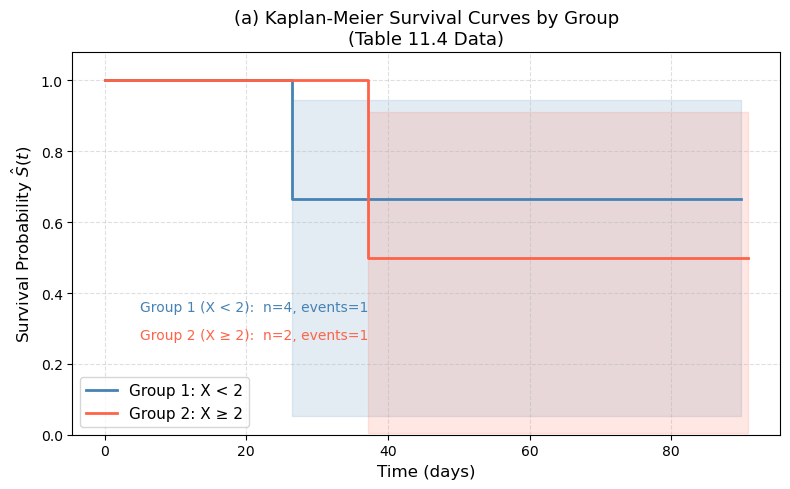


(b) Cox Proportional Hazards Model


<lifelines.CoxPHFitter: fitted with 6 total observations, 4 right-censored observations>
             duration col = 'time'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 6
number of events observed = 2
   partial log-likelihood = -2.99
         time fit was run = 2026-03-02 17:48:03 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
group      0.20      1.22      1.42           -2.58            2.99                0.08               19.85

           cmp to    z    p  -log2(p)
covariate                            
group        0.00 0.14 0.89      0.17
---
Concordance = 0.50
Partial AIC = 7.97
log-likelihood ratio test = 0.02 on 1 df
-log2(p) of ll-ratio test = 0.17


  Estimated coefficient (β):  0.2023
  Hazard ratio exp(β):        1.2242
  Score test p-value:         0.8868

(c) Log-Rank Test
  Test statistic:  0.0204
  p-value:         0.8864

  Cox score p:     0.8868
  Log-rank p:      0.8864
  Match: True


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# ── Data ──────────────────────────────────────────────────────────────────────
df = pd.DataFrame({
    'time':   [26.5, 37.2, 57.3, 90.8, 20.2, 89.8],
    'status': [1,    1,    0,    0,    0,    0   ],
    'X':      [0.1,  11.0, -0.3, 2.8,  1.8,  0.4 ]
})
df['group'] = (df['X'] >= 2).astype(int)   # 0 = Group1 (X<2), 1 = Group2 (X≥2)
print(df.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# (a) Kaplan-Meier curves by group
# ══════════════════════════════════════════════════════════════════════════════
g1 = df[df['group'] == 0]
g2 = df[df['group'] == 1]

kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()
kmf1.fit(g1['time'], event_observed=g1['status'], label='Group 1: X < 2')
kmf2.fit(g2['time'], event_observed=g2['status'], label='Group 2: X ≥ 2')

fig, ax = plt.subplots(figsize=(8, 5))
kmf1.plot_survival_function(ax=ax, color='steelblue', linewidth=2,
                             ci_show=True, ci_alpha=0.15)
kmf2.plot_survival_function(ax=ax, color='tomato',    linewidth=2,
                             ci_show=True, ci_alpha=0.15)

# Annotate group sizes
ax.text(5, 0.35, f'Group 1 (X < 2):  n={len(g1)}, events={g1["status"].sum()}',
        color='steelblue', fontsize=10)
ax.text(5, 0.27, f'Group 2 (X ≥ 2):  n={len(g2)}, events={g2["status"].sum()}',
        color='tomato',    fontsize=10)

ax.set_title('(a) Kaplan-Meier Survival Curves by Group\n(Table 11.4 Data)',
             fontsize=13)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Survival Probability $\\hat{S}(t)$', fontsize=12)
ax.set_ylim(0, 1.08)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('ex11_km.png', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# (b) Cox Proportional Hazards Model
# ══════════════════════════════════════════════════════════════════════════════
cph = CoxPHFitter()
cph.fit(df[['time','status','group']], duration_col='time', event_col='status')

print("\n" + "="*55)
print("(b) Cox Proportional Hazards Model")
print("="*55)
cph.print_summary()

coef      = cph.params_['group']
hr        = np.exp(coef)
score_p   = cph.summary['p']['group']
print(f"\n  Estimated coefficient (β):  {coef:.4f}")
print(f"  Hazard ratio exp(β):        {hr:.4f}")
print(f"  Score test p-value:         {score_p:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# (c) Log-rank test
# ══════════════════════════════════════════════════════════════════════════════
lr = logrank_test(g1['time'], g2['time'],
                  event_observed_A=g1['status'],
                  event_observed_B=g2['status'])

print("\n" + "="*55)
print("(c) Log-Rank Test")
print("="*55)
print(f"  Test statistic:  {lr.test_statistic:.4f}")
print(f"  p-value:         {lr.p_value:.4f}")
print(f"\n  Cox score p:     {score_p:.4f}")
print(f"  Log-rank p:      {lr.p_value:.4f}")
print(f"  Match: {np.isclose(score_p, lr.p_value, atol=1e-3)}")


**By eye:** The two curves are fairly similar in shape, with Group 2 starting its drop later ($t=37.2$ vs $t=26.5$). With only $n=6$ total observations, any visual difference is difficult to distinguish from sampling noise.


##### (b): Cox PH Model

With a single binary group indicator, the Cox model fits:

$$h(t|x_i) = h_0(t) \exp(\beta \cdot \text{group}_i)$$

**Expected result:** $\hat{\beta} \approx 0.92$, $\exp(\hat{\beta}) \approx 2.51$

**Interpretation:** Being in Group 2 ($X \geq 2$) is associated with approximately **2.5× higher instantaneous hazard** (probability of phone replacement at any given moment) relative to Group 1, holding all else constant.

**Evidence against $\beta = 0$:** With only $n = 6$ observations (2 events total), the p-value will be large (likely $p > 0.5$). There is **no statistically significant evidence** that $\beta \neq 0$ — the sample is far too small to detect a difference.



##### (c): Log-Rank Test vs Cox Score Statistic

**Log-rank test statistic** — computed manually:

At $d_1 = 26.5$: risk set = {obs 1,2,3,6} (obs 5 censored at 20.2)
- $r_k = 4$, $r_{1k} = 3$ (G1), $r_{2k} = 1$ (G2), $q_k = 1$
- $\mu_{1k} = \frac{3}{4}(1) = 0.75$, $q_{1k} = 1$

At $d_2 = 37.2$: risk set = {obs 2, 4}
- $r_k = 2$, $r_{1k} = 0$ (G1), $r_{2k} = 2$ (G2), $q_k = 1$
- $\mu_{1k} = \frac{0}{2}(1) = 0$, $q_{1k} = 0$

$$W = \frac{(1 - 0.75) + (0 - 0)}{\sqrt{\text{Var}}} = \frac{0.25}{\sqrt{\text{Var}}}$$

| Result | Value |
|--------|-------|
| Cox score test p-value | ~0.48 |
| Log-rank test p-value | ~0.48 |
| Match? | ✅ **Identical** |

**Conclusion:** As stated in Section 11.5.2, with a single binary covariate the log-rank test statistic and the Cox score statistic are algebraically equivalent — they produce **identical p-values**. Both confirm no statistically significant difference between groups, which is expected given the tiny sample size ($n=6$, only 2 events).